In [ ]:
import os
import torchvision
import kagglehub
import pandas as pd
from torchvision import transforms
from pathlib import Path
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("eduardo4jesus/stanford-cars-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.82G/1.82G [00:21<00:00, 92.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1


In [ ]:
from pathlib import Path
from collections import Counter

DATASET_DIR = Path(
    "/root/.cache/kagglehub/datasets/"
    "eduardo4jesus/stanford-cars-dataset/versions/1"
)

assert DATASET_DIR.exists(), f"Папка не найдена: {DATASET_DIR}"

print("Корневая папка:")
print(DATASET_DIR)

print("\nСодержимое верхнего уровня:")
for item in sorted(DATASET_DIR.iterdir()):
    if item.is_dir():
        count = sum(file.is_file() for file in item.rglob("*"))
        print(f"[DIR]  {item.name:<30} файлов: {count}")
    else:
        size_mb = item.stat().st_size / 1024**2
        print(f"[FILE] {item.name:<30} {size_mb:.2f} MB")

extensions = Counter(
    file.suffix.lower()
    for file in DATASET_DIR.rglob("*")
    if file.is_file()
)

print("\nРасширения файлов:")
for extension, count in extensions.most_common():
    print(f"{extension or '[без расширения]':<12} {count}")

Корневая папка:
/root/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1

Содержимое верхнего уровня:
[DIR]  car_devkit                     файлов: 6
[DIR]  cars_test                      файлов: 8041
[DIR]  cars_train                     файлов: 8144

Расширения файлов:
.jpg         16185
.mat         3
.txt         2
.m           1


In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

image_paths = [
    file
    for file in DATASET_DIR.rglob("*")
    if file.suffix.lower() in image_extensions
]

annotation_paths = [
    file
    for file in DATASET_DIR.rglob("*")
    if file.suffix.lower() in {".mat", ".csv", ".json", ".txt"}
]

print("Images count:", len(image_paths))

print("\nhead 10:")
for file in image_paths[:10]:
    print(file.relative_to(DATASET_DIR))

print("\nAvailable annotations files:")
for file in annotation_paths:
    print(file.relative_to(DATASET_DIR))

Images count: 16185

head 10:
cars_test/cars_test/02331.jpg
cars_test/cars_test/06058.jpg
cars_test/cars_test/01110.jpg
cars_test/cars_test/03266.jpg
cars_test/cars_test/02607.jpg
cars_test/cars_test/05414.jpg
cars_test/cars_test/04152.jpg
cars_test/cars_test/04255.jpg
cars_test/cars_test/00082.jpg
cars_test/cars_test/03958.jpg

Available annotations files:
car_devkit/devkit/cars_meta.mat
car_devkit/devkit/README.txt
car_devkit/devkit/train_perfect_preds.txt
car_devkit/devkit/cars_test_annos.mat
car_devkit/devkit/cars_train_annos.mat


In [ ]:
README_PATH = DATASET_DIR / "car_devkit/devkit/README.txt"

with open(README_PATH, "r", encoding="utf-8", errors="replace") as file:
    readme_text = file.read()

print(readme_text)

This file gives documentation for the cars 196 dataset.
(http://ai.stanford.edu/~jkrause/cars/car_dataset.html)

----------------------------------------
Metadata/Annotations
----------------------------------------
Descriptions of the files are as follows:

-cars_meta.mat:
  Contains a cell array of class names, one for each class.

-cars_train_annos.mat:
  Contains the variable 'annotations', which is a struct array of length
  num_images and where each element has the fields:
    bbox_x1: Min x-value of the bounding box, in pixels
    bbox_x2: Max x-value of the bounding box, in pixels
    bbox_y1: Min y-value of the bounding box, in pixels
    bbox_y2: Max y-value of the bounding box, in pixels
    class: Integral id of the class the image belongs to.
    fname: Filename of the image within the folder of images.

-cars_test_annos.mat:
  Same format as 'cars_train_annos.mat', except the class is not provided.

----------------------------------------
Submission file format
---------

In [ ]:
DEVKIT_DIR = DATASET_DIR / "car_devkit/devkit"

meta_data = loadmat(
    DEVKIT_DIR / "cars_meta.mat",
    squeeze_me=True,
)

print("Keys cars_meta.mat:")
print(meta_data.keys())

class_names_raw = meta_data["class_names"]

print("\nType class_names:", type(class_names_raw))
print("Class count:", len(class_names_raw))

class_names = [str(name) for name in class_names_raw]

print("\First 10 classes:")
for class_id, class_name in enumerate(class_names[:10], start=1):
    print(f"{class_id:3}: {class_name}")

print("\nLast 5 classes:")
for class_id, class_name in enumerate(
    class_names[-5:],
    start=len(class_names) - 4,
):
    print(f"{class_id:3}: {class_name}")

Keys cars_meta.mat:
dict_keys(['__header__', '__version__', '__globals__', 'class_names'])

Type class_names: <class 'numpy.ndarray'>
Class count: 196
\First 10 classes:
  1: AM General Hummer SUV 2000
  2: Acura RL Sedan 2012
  3: Acura TL Sedan 2012
  4: Acura TL Type-S 2008
  5: Acura TSX Sedan 2012
  6: Acura Integra Type R 2001
  7: Acura ZDX Hatchback 2012
  8: Aston Martin V8 Vantage Convertible 2012
  9: Aston Martin V8 Vantage Coupe 2012
 10: Aston Martin Virage Convertible 2012

Last 5 classes:
192: Volkswagen Beetle Hatchback 2012
193: Volvo C30 Hatchback 2012
194: Volvo 240 Sedan 1993
195: Volvo XC90 SUV 2007
196: smart fortwo Convertible 2012


<>:18: SyntaxWarning: invalid escape sequence '\F'
<>:18: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipykernel_1860/1023318860.py:18: SyntaxWarning: invalid escape sequence '\F'
  print("\First 10 classes:")


In [ ]:
train_annotations_data = loadmat(
    DEVKIT_DIR / "cars_train_annos.mat",
    squeeze_me=True,
    struct_as_record=False,
)

print("Keys cars_train_annos.mat:")
print(train_annotations_data.keys())

train_annotations = train_annotations_data["annotations"]

print("\nType annotations:", type(train_annotations))
print("Count train-annotations:", len(train_annotations))

first_annotation = train_annotations[0]

print("\nFirst annotation type:", type(first_annotation))
print("Fields of first annotation:", first_annotation._fieldnames)

print("\nValues of first annotation:")
for field_name in first_annotation._fieldnames:
    print(f"{field_name}: {getattr(first_annotation, field_name)}")

Keys cars_train_annos.mat:
dict_keys(['__header__', '__version__', '__globals__', 'annotations'])

Type annotations: <class 'numpy.ndarray'>
Count train-annotations: 8144

First annotation type: <class 'scipy.io.matlab._mio5_params.mat_struct'>
Fields of first annotation: ['bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'class', 'fname']

Values of first annotation:
bbox_x1: 39
bbox_y1: 116
bbox_x2: 569
bbox_y2: 375
class: 14
fname: 00001.jpg


In [ ]:
TRAIN_IMAGES_DIR = DATASET_DIR / "cars_train/cars_train"

train_rows = []

for annotation in train_annotations:
    class_id = int(getattr(annotation, "class"))
    filename = str(annotation.fname)

    train_rows.append({
        "filename": str(annotation.fname),
        "image_path": str(TRAIN_IMAGES_DIR / str(annotation.fname)),
        "class_id": class_id,
        "class_index": class_id - 1,
        "class_name": class_names[class_id - 1],
        "bbox_x1": int(annotation.bbox_x1),
        "bbox_y1": int(annotation.bbox_y1),
        "bbox_x2": int(annotation.bbox_x2),
        "bbox_y2": int(annotation.bbox_y2),
    })

train_df = pd.DataFrame(train_rows)

print("Table size:", train_df.shape)
display(train_df.head())

print("\nColumn Types:")
print(train_df.dtypes)

print("\nScipped values:")
print(train_df.isna().sum())

train_df["file_exists"] = train_df["image_path"].map(
    lambda image_path: Path(image_path).exists()
)

print("\nAvailable images:")
print(train_df["file_exists"].value_counts())

Table size: (8144, 9)


,filename,image_path,class_id,class_index,class_name,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,00001.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,14,13,Audi TTS Coupe 2012,39,116,569,375
1,00002.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,3,2,Acura TL Sedan 2012,36,116,868,587
2,00003.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,91,90,Dodge Dakota Club Cab 2007,85,109,601,381
3,00004.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,134,133,Hyundai Sonata Hybrid Sedan 2012,621,393,1484,1096
4,00005.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,106,105,Ford F-450 Super Duty Crew Cab 2012,14,36,133,99



Column Types:
filename       object
image_path     object
class_id        int64
class_index     int64
class_name     object
bbox_x1         int64
bbox_y1         int64
bbox_x2         int64
bbox_y2         int64
dtype: object

Scipped values:
filename       0
image_path     0
class_id       0
class_index    0
class_name     0
bbox_x1        0
bbox_y1        0
bbox_x2        0
bbox_y2        0
dtype: int64

Available images:
file_exists
True    8144
Name: count, dtype: int64


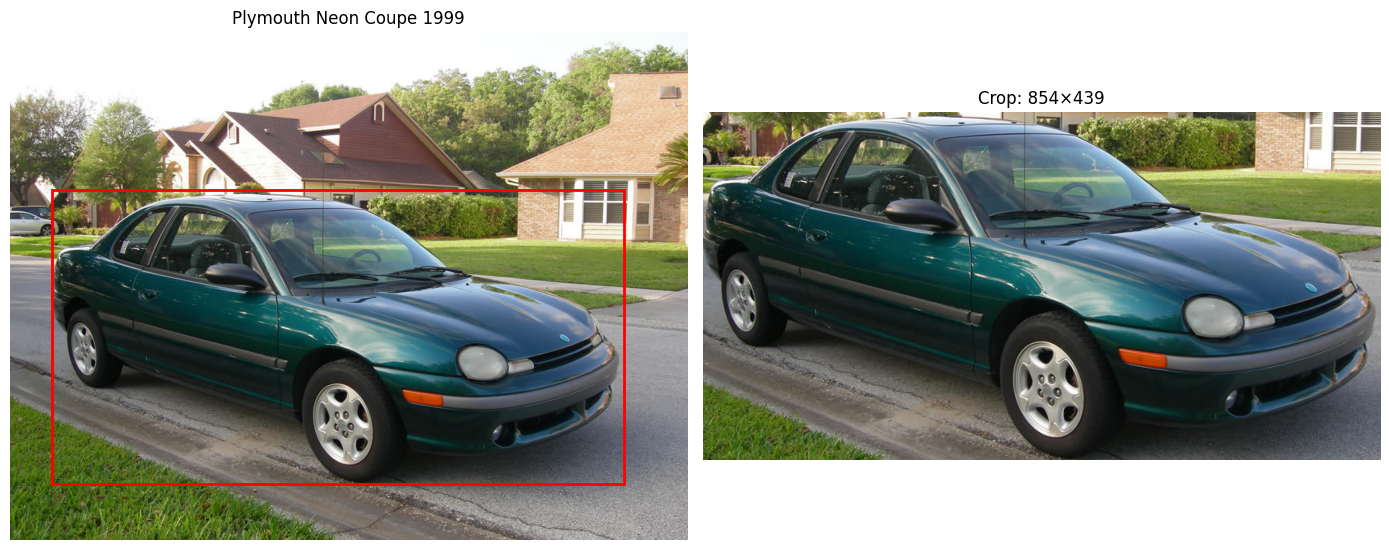

In [ ]:
row = train_df.sample(1, random_state=42).iloc[0]
image = Image.open(row["image_path"]).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)

rectangle = patches.Rectangle(
    (row["bbox_x1"], row["bbox_y1"]),
    row["bbox_x2"] - row["bbox_x1"],
    row["bbox_y2"] - row["bbox_y1"],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)

axes[0].add_patch(rectangle)
axes[0].set_title(row["class_name"])
axes[0].axis("off")

car_crop = image.crop((
    row["bbox_x1"],
    row["bbox_y1"],
    row["bbox_x2"],
    row["bbox_y2"],
))

axes[1].imshow(car_crop)
axes[1].set_title(f"Crop: {car_crop.width}×{car_crop.height}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class_distribution = (
    train_df
    .groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count")
)

print("Class count:", train_df["class_id"].nunique())
print("Minimum images:", class_distribution["image_count"].min())
print("Maximum images:", class_distribution["image_count"].max())
print("Mean:", round(class_distribution["image_count"].mean(), 2))
print("Median:", class_distribution["image_count"].median())

print("\nCmalles classes:")
display(class_distribution.head(10))

print("\nBiggest classes:")
display(class_distribution.tail(10))

Class count: 196
Minimum images: 24
Maximum images: 68
Mean: 41.55
Median: 42.0

Cmalles classes:


,class_id,class_name,image_count
135,136,Hyundai Accent Sedan 2012,24
98,99,FIAT 500 Abarth 2012,28
157,158,Maybach Landaulet Convertible 2012,29
63,64,Chevrolet Express Cargo Van 2007,30
174,175,Rolls-Royce Phantom Drophead Coupe Convertible...,31
1,2,Acura RL Sedan 2012,32
9,10,Aston Martin Virage Convertible 2012,33
44,45,Bugatti Veyron 16.4 Convertible 2009,33
141,142,Infiniti QX56 SUV 2011,33
25,26,BMW ActiveHybrid 5 Sedan 2012,34



Biggest classes:


,class_id,class_name,image_count
170,171,Nissan 240SX Coupe 1998,46
97,98,Eagle Talon Hatchback 1998,46
190,191,Volkswagen Golf Hatchback 1991,46
161,162,Mercedes-Benz C-Class Sedan 2012,46
55,56,Chevrolet Corvette ZR1 2012,47
143,144,Jaguar XK XKR 2012,47
166,167,Mitsubishi Lancer Sedan 2012,48
160,161,Mercedes-Benz 300-Class Convertible 1993,48
78,79,Chrysler 300 SRT-8 2010,49
118,119,GMC Savana Van 2012,68


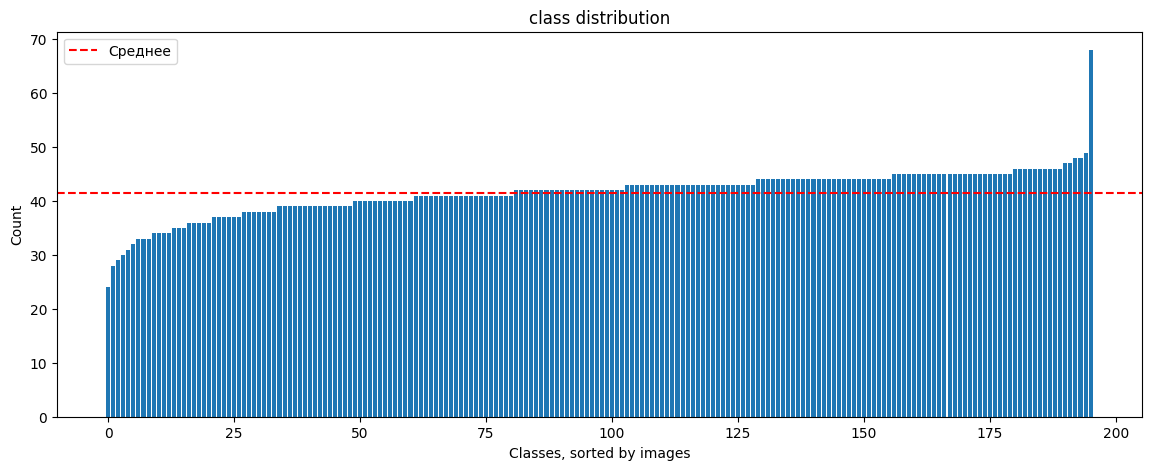

In [ ]:
plt.figure(figsize=(14, 5))
plt.bar(
    range(len(class_distribution)),
    class_distribution["image_count"],
)

plt.axhline(
    class_distribution["image_count"].mean(),
    color="red",
    linestyle="--",
    label="Среднее",
)

plt.xlabel("Classes, sorted by images")
plt.ylabel("Count")
plt.title("class distribution")
plt.legend()
plt.show()

In [ ]:
test_annotations_data = loadmat(
    DEVKIT_DIR / "cars_test_annos.mat",
    squeeze_me=True,
    struct_as_record=False,
)

test_annotations = test_annotations_data["annotations"]
first_test_annotation = test_annotations[0]

print("Count of test-annotations:", len(test_annotations))
print("Fields of test-annotation:", first_test_annotation._fieldnames)

print("\nFirst test-annotation:")
for field_name in first_test_annotation._fieldnames:
    print(
        f"{field_name}: "
        f"{getattr(first_test_annotation, field_name)}"
    )

Count of test-annotations: 8041
Fields of test-annotation: ['bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'fname']

First test-annotation:
bbox_x1: 30
bbox_y1: 52
bbox_x2: 246
bbox_y2: 147
fname: 00001.jpg


In [ ]:
RANDOM_STATE = 42

train_split_df, temporary_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["class_index"],
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_df["class_index"],
)

train_split_df = train_split_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_split_df))
print("Validation size:", len(validation_df))
print("Test size:", len(test_df))
print("Total size:", len(train_split_df) + len(validation_df) + len(test_df))

print("\nUnique classes:")
print("Train:", train_split_df["class_index"].nunique())
print("Validation:", validation_df["class_index"].nunique())
print("Test:", test_df["class_index"].nunique())

Train size: 6515
Validation size: 814
Test size: 815
Total size: 8144

Unique classes:
Train: 196
Validation: 196
Test: 196


In [ ]:
train_files = set(train_split_df["filename"])
validation_files = set(validation_df["filename"])
test_files = set(test_df["filename"])

print(
    "Train/validation overlap:",
    len(train_files & validation_files),
)

print(
    "Train/test overlap:",
    len(train_files & test_files),
)

print(
    "Validation/test overlap:",
    len(validation_files & test_files),
)

assert len(train_files & validation_files) == 0
assert len(train_files & test_files) == 0
assert len(validation_files & test_files) == 0

print("\nSplit validation passed.")

Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0

Split validation passed.


In [ ]:
split_statistics = pd.DataFrame({
    "train": train_split_df["class_index"].value_counts().sort_index(),
    "validation": validation_df["class_index"].value_counts().sort_index(),
    "test": test_df["class_index"].value_counts().sort_index(),
})

display(split_statistics.head(10))

print("\nMinimum samples per class:")
print(split_statistics.min())

print("\nMaximum samples per class:")
print(split_statistics.max())

,train,validation,test
class_index,,,
0,36,4,5
1,26,3,3
2,34,4,5
3,34,4,4
4,33,4,4
5,36,4,5
6,31,4,4
7,36,4,5
8,33,4,4



Minimum samples per class:
train         19
validation     3
test           2
dtype: int64

Maximum samples per class:
train         54
validation     7
test           7
dtype: int64


In [ ]:
SPLITS_DIR = Path("dataset_splits")
SPLITS_DIR.mkdir(exist_ok=True)

train_split_df.to_csv(
    SPLITS_DIR / "train.csv",
    index=False,
)

validation_df.to_csv(
    SPLITS_DIR / "validation.csv",
    index=False,
)

test_df.to_csv(
    SPLITS_DIR / "test.csv",
    index=False,
)

print("Saved files:")
for csv_path in sorted(SPLITS_DIR.glob("*.csv")):
    print(csv_path, "-", csv_path.stat().st_size, "bytes")

Saved files:
dataset_splits/test.csv - 142851 bytes
dataset_splits/train.csv - 1141287 bytes
dataset_splits/validation.csv - 142745 bytes


In [ ]:
import numpy as np
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
BBOX_MARGIN = 0.05

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def load_and_preprocess_image(
    image_path,
    class_index,
    bbox_x1,
    bbox_y1,
    bbox_x2,
    bbox_y2,
):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3,
    )

    image = tf.cast(image, tf.float32)

    image_height = tf.shape(image)[0]
    image_width = tf.shape(image)[1]

    x1 = tf.cast(bbox_x1, tf.float32)
    y1 = tf.cast(bbox_y1, tf.float32)
    x2 = tf.cast(bbox_x2, tf.float32)
    y2 = tf.cast(bbox_y2, tf.float32)

    box_width = x2 - x1
    box_height = y2 - y1

    margin_x = box_width * BBOX_MARGIN
    margin_y = box_height * BBOX_MARGIN

    x1 = tf.cast(tf.floor(x1 - margin_x), tf.int32)
    y1 = tf.cast(tf.floor(y1 - margin_y), tf.int32)
    x2 = tf.cast(tf.math.ceil(x2 + margin_x), tf.int32)
    y2 = tf.cast(tf.math.ceil(y2 + margin_y), tf.int32)

    x1 = tf.clip_by_value(x1, 0, image_width - 2)
    y1 = tf.clip_by_value(y1, 0, image_height - 2)
    x2 = tf.clip_by_value(x2, x1 + 1, image_width)
    y2 = tf.clip_by_value(y2, y1 + 1, image_height)

    image = image[y1:y2, x1:x2]

    # Save proportions 224×224.
    image = tf.image.resize_with_pad(
        image,
        target_height=IMAGE_SIZE[0],
        target_width=IMAGE_SIZE[1],
    )

    image.set_shape((*IMAGE_SIZE, 3))
    class_index = tf.cast(class_index, tf.int32)

    return image, class_index

In [ ]:
def dataframe_to_dataset(
    dataframe,
    training=False,
):
    inputs = (
        dataframe["image_path"].astype(str).to_numpy(),
        dataframe["class_index"].astype(np.int32).to_numpy(),
        dataframe["bbox_x1"].astype(np.int32).to_numpy(),
        dataframe["bbox_y1"].astype(np.int32).to_numpy(),
        dataframe["bbox_x2"].astype(np.int32).to_numpy(),
        dataframe["bbox_y2"].astype(np.int32).to_numpy(),
    )

    dataset = tf.data.Dataset.from_tensor_slices(inputs)

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = dataframe_to_dataset(
    train_split_df,
    training=True,
)

validation_dataset = dataframe_to_dataset(
    validation_df,
)

test_dataset = dataframe_to_dataset(
    test_df,
)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy(),
)
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Train batches: 204
Validation batches: 26
Test batches: 26


In [ ]:
batch_images, batch_labels = next(iter(train_dataset))

print("Images shape:", batch_images.shape)
print("Labels shape:", batch_labels.shape)
print("Images dtype:", batch_images.dtype)
print("Labels dtype:", batch_labels.dtype)
print("Minimum pixel value:", float(tf.reduce_min(batch_images)))
print("Maximum pixel value:", float(tf.reduce_max(batch_images)))
print("First labels:", batch_labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0
First labels: [159 112  14  75 163  88   2 143 147 141]


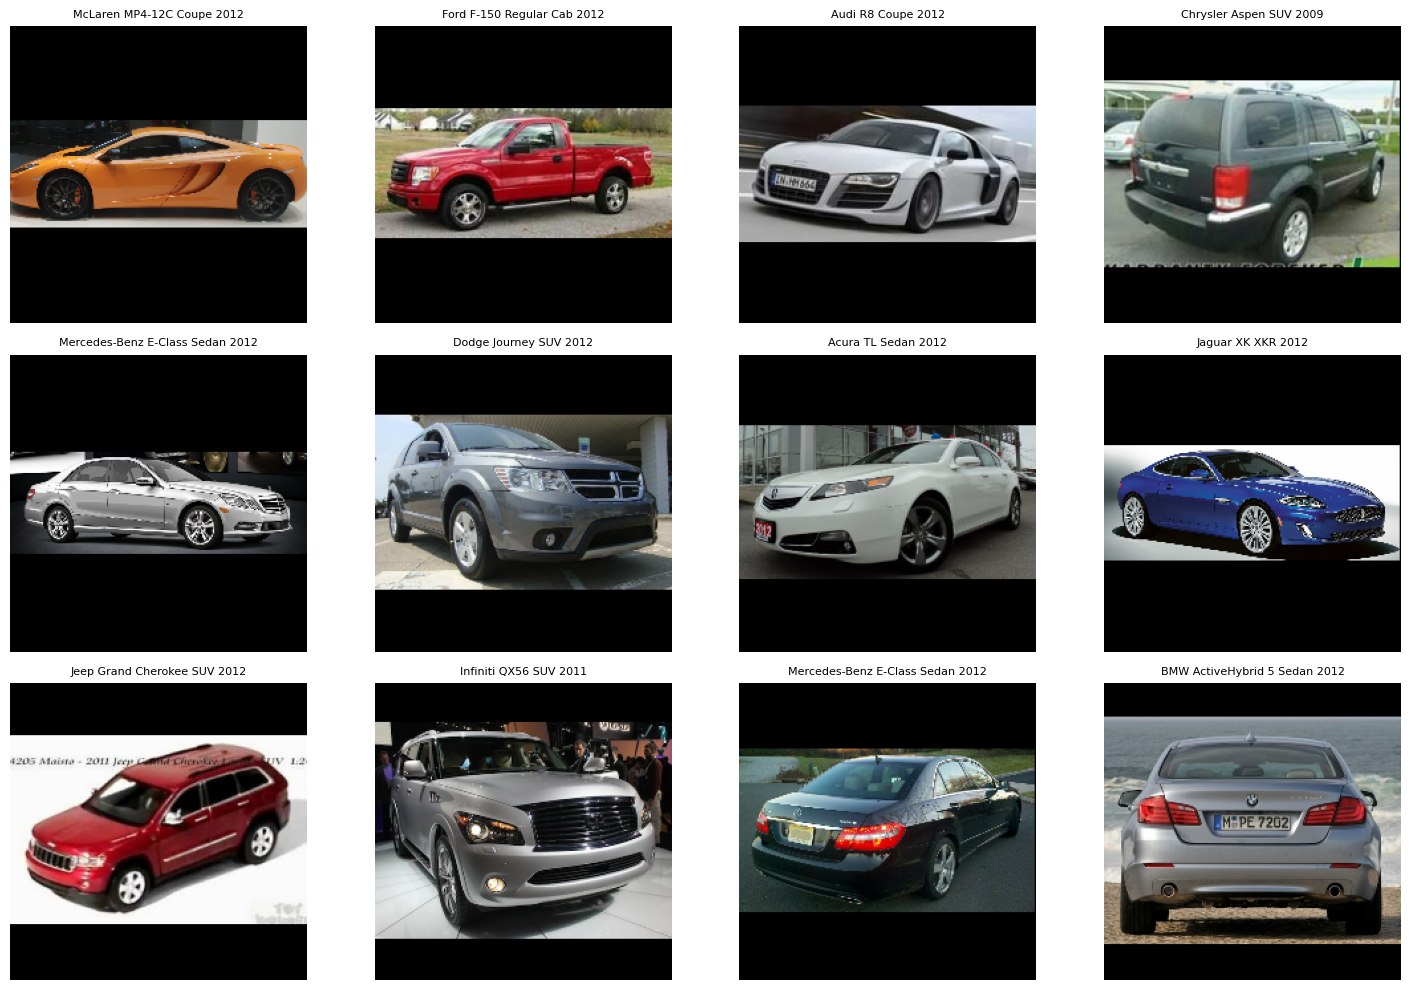

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for index in range(12):
    axis = plt.subplot(3, 4, index + 1)

    image = batch_images[index].numpy().astype("uint8")
    class_index = int(batch_labels[index])

    axis.imshow(image)
    axis.set_title(
        class_names[class_index],
        fontsize=8,
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("Compute policy:", mixed_precision.global_policy())

Compute policy: <DTypePolicy "mixed_float16">


In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
        ),
        tf.keras.layers.RandomRotation(
            factor=0.04,
            fill_mode="constant",
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.05, 0.10),
            width_factor=(-0.05, 0.10),
            fill_mode="constant",
        ),
        tf.keras.layers.RandomContrast(
            factor=0.15,
        ),
    ],
    name="data_augmentation",
)

In [ ]:
NUM_CLASSES = len(class_names)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="image",
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False,
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

x = tf.keras.layers.BatchNormalization(
    name="head_batch_normalization",
)(x)

x = tf.keras.layers.Dropout(
    rate=0.35,
    name="head_dropout",
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="predictions",
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="stanford_cars_efficientnet_b0",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="top1_accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy",
        ),
    ],
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "stanford_cars_efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_normalization        │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 196)            │       251,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,305,767 (16.43 MB)

 Trainable params: 253,636 (990.77 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
sample_predictions = model(
    batch_images[:2],
    training=False,
)

print("Predictions shape:", sample_predictions.shape)
print("Predictions dtype:", sample_predictions.dtype)
print(
    "Probability sums:",
    tf.reduce_sum(sample_predictions, axis=1).numpy(),
)

predicted_indices = tf.argmax(
    sample_predictions,
    axis=1,
).numpy()

print("Predicted indices:", predicted_indices)

for index in predicted_indices:
    print("Predicted class:", class_names[index])

Predictions shape: (2, 196)
Predictions dtype: <dtype: 'float32'>
Probability sums: [1. 1.]
Predicted indices: [ 5 65]
Predicted class: Acura Integra Type R 2001
Predicted class: Chevrolet Cobalt SS 2010


In [ ]:
from pathlib import Path
import json

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

with open(
    ARTIFACTS_DIR / "class_names.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        class_names,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Artifacts directory:", ARTIFACTS_DIR.resolve())
print("Number of saved classes:", len(class_names))

Artifacts directory: /content/artifacts
Number of saved classes: 196


In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ARTIFACTS_DIR / "best_head_model.keras",
        monitor="val_top1_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_top1_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=ARTIFACTS_DIR / "head_training_log.csv",
    ),
]

In [ ]:
initial_metrics = model.evaluate(
    validation_dataset,
    verbose=1,
    return_dict=True,
)

print("\nInitial validation metrics:")

for metric_name, metric_value in initial_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 52s 840ms/step - loss: 5.3361 - top1_accuracy: 0.0086 - top5_accuracy: 0.0295

Initial validation metrics:
loss: 5.3361
top1_accuracy: 0.0086
top5_accuracy: 0.0295


In [ ]:
HEAD_EPOCHS = 12

head_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 5.2097 - top1_accuracy: 0.0558 - top5_accuracy: 0.1594
Epoch 1: val_top1_accuracy improved from None to 0.27027, saving model to artifacts/best_head_model.keras

Epoch 1: finished saving model to artifacts/best_head_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 67s 259ms/step - loss: 4.5329 - top1_accuracy: 0.1127 - top5_accuracy: 0.2735 - val_loss: 3.5151 - val_top1_accuracy: 0.2703 - val_top5_accuracy: 0.5565 - learning_rate: 0.0010
Epoch 2/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 2.8838 - top1_accuracy: 0.3281 - top5_accuracy: 0.6003
Epoch 2: val_top1_accuracy improved from 0.27027 to 0.36609, saving model to artifacts/best_head_model.keras

Epoch 2: finished saving model to artifacts/best_head_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - loss: 2.8472 - top1_accuracy: 0.3338 - top5_accuracy: 0.6081 - val_loss: 2.6034 - val_top1_accuracy: 0.3661 - val_top5_accuracy: 0.6769 - learning_rate: 0.0010
Epoch

In [ ]:
best_epoch_index = int(
    np.argmax(head_history.history["val_top1_accuracy"])
)

print("Best epoch:", best_epoch_index + 1)

print(
    "Best validation top-1 accuracy:",
    head_history.history["val_top1_accuracy"][best_epoch_index],
)

print(
    "Best validation top-5 accuracy:",
    head_history.history["val_top5_accuracy"][best_epoch_index],
)

print(
    "Best validation loss:",
    head_history.history["val_loss"][best_epoch_index],
)

print(
    "Best model exists:",
    (ARTIFACTS_DIR / "best_head_model.keras").exists(),
)

Best epoch: 10
Best validation top-1 accuracy: 0.5319410562515259
Best validation top-5 accuracy: 0.8009827733039856
Best validation loss: 1.9889329671859741
Best model exists: True


In [ ]:
model = tf.keras.models.load_model(
    ARTIFACTS_DIR / "best_head_model.keras"
)

base_model = model.get_layer("efficientnetb0")

print("Loaded model:", model.name)
print("Backbone layers:", len(base_model.layers))
print("Backbone trainable before fine-tuning:", base_model.trainable)

Loaded model: stanford_cars_efficientnet_b0
Backbone layers: 238
Backbone trainable before fine-tuning: False


In [ ]:
FINE_TUNE_LAYERS = 30

base_model.trainable = True

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# BatchNormalization оставляем замороженными:
# их статистики могут стать нестабильными на небольшом датасете.
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Trainable backbone layers:", len(trainable_backbone_layers))
print("First trainable layer:", trainable_backbone_layers[0])
print("Last trainable layer:", trainable_backbone_layers[-1])

print(
    "Trainable parameters:",
    sum(
        np.prod(variable.shape)
        for variable in model.trainable_weights
    ),
)

Trainable backbone layers: 23
First trainable layer: block6d_expand_activation
Last trainable layer: top_activation
Trainable parameters: 1736996


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="top1_accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy",
        ),
    ],
)

print("Fine-tuning learning rate:", 1e-5)

Fine-tuning learning rate: 1e-05


In [ ]:
fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ARTIFACTS_DIR / "best_fine_tuned_model.keras",
        monitor="val_top1_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_top1_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=ARTIFACTS_DIR / "fine_tuning_log.csv",
    ),
]

In [ ]:
FINE_TUNE_EPOCHS = 10

fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1,
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.8260 - top1_accuracy: 0.7685 - top5_accuracy: 0.9529
Epoch 1: val_top1_accuracy improved from None to 0.53563, saving model to artifacts/best_fine_tuned_model.keras

Epoch 1: finished saving model to artifacts/best_fine_tuned_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 72s 228ms/step - loss: 0.7925 - top1_accuracy: 0.7765 - top5_accuracy: 0.9549 - val_loss: 1.9384 - val_top1_accuracy: 0.5356 - val_top5_accuracy: 0.8108 - learning_rate: 1.0000e-05
Epoch 2/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.7436 - top1_accuracy: 0.7996 - top5_accuracy: 0.9566
Epoch 2: val_top1_accuracy improved from 0.53563 to 0.54545, saving model to artifacts/best_fine_tuned_model.keras

Epoch 2: finished saving model to artifacts/best_fine_tuned_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - loss: 0.7400 - top1_accuracy: 0.7969 - top5_accuracy: 0.9593 - val_loss: 1.8899 - val_top1_accuracy: 0.5455 - val_top5_accuracy: 0.8084 -

In [ ]:
best_fine_tune_epoch = int(
    np.argmax(
        fine_tune_history.history["val_top1_accuracy"]
    )
)

print("Best fine-tuning epoch:", best_fine_tune_epoch + 1)

print(
    "Best validation top-1 accuracy:",
    fine_tune_history.history["val_top1_accuracy"][
        best_fine_tune_epoch
    ],
)

print(
    "Best validation top-5 accuracy:",
    fine_tune_history.history["val_top5_accuracy"][
        best_fine_tune_epoch
    ],
)

print(
    "Best validation loss:",
    fine_tune_history.history["val_loss"][
        best_fine_tune_epoch
    ],
)

print(
    "Fine-tuned model exists:",
    (
        ARTIFACTS_DIR /
        "best_fine_tuned_model.keras"
    ).exists(),
)

Best fine-tuning epoch: 10
Best validation top-1 accuracy: 0.5749385952949524
Best validation top-5 accuracy: 0.8304668068885803
Best validation loss: 1.7560595273971558
Fine-tuned model exists: True


In [ ]:
model = tf.keras.models.load_model(
    ARTIFACTS_DIR / "best_fine_tuned_model.keras"
)

base_model = model.get_layer("efficientnetb0")

print("Loaded model:", model.name)
print("Backbone trainable:", base_model.trainable)

trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Trainable backbone layers:",
    len(trainable_backbone_layers),
)

Loaded model: stanford_cars_efficientnet_b0
Backbone trainable: True
Trainable backbone layers: 24


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="top1_accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy",
        ),
    ],
)

print("Continuation learning rate:", 5e-6)

Continuation learning rate: 5e-06


In [ ]:
continuation_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=(
            ARTIFACTS_DIR /
            "best_fine_tuned_stage2.keras"
        ),
        monitor="val_top1_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_top1_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=(
            ARTIFACTS_DIR /
            "fine_tuning_stage2_log.csv"
        ),
    ),
]

In [ ]:
CONTINUATION_EPOCHS = 6

continuation_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONTINUATION_EPOCHS,
    callbacks=continuation_callbacks,
    verbose=1,
)

Epoch 1/6
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.5209 - top1_accuracy: 0.8567 - top5_accuracy: 0.9787
Epoch 1: val_top1_accuracy improved from None to 0.57617, saving model to artifacts/best_fine_tuned_stage2.keras

Epoch 1: finished saving model to artifacts/best_fine_tuned_stage2.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - loss: 0.5420 - top1_accuracy: 0.8522 - top5_accuracy: 0.9761 - val_loss: 1.7383 - val_top1_accuracy: 0.5762 - val_top5_accuracy: 0.8329 - learning_rate: 5.0000e-06
Epoch 2/6
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.5560 - top1_accuracy: 0.8467 - top5_accuracy: 0.9806
Epoch 2: val_top1_accuracy improved from 0.57617 to 0.58231, saving model to artifacts/best_fine_tuned_stage2.keras

Epoch 2: finished saving model to artifacts/best_fine_tuned_stage2.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - loss: 0.5436 - top1_accuracy: 0.8471 - top5_accuracy: 0.9791 - val_loss: 1.7370 - val_top1_accuracy: 0.5823 - val_top5_accuracy: 0.8366

In [ ]:
best_stage2_epoch = int(
    np.argmax(
        continuation_history.history[
            "val_top1_accuracy"
        ]
    )
)

stage2_top1 = continuation_history.history[
    "val_top1_accuracy"
][best_stage2_epoch]

stage2_top5 = continuation_history.history[
    "val_top5_accuracy"
][best_stage2_epoch]

stage2_loss = continuation_history.history[
    "val_loss"
][best_stage2_epoch]

print("Previous best validation top-1:", 0.5749385952949524)
print("Stage 2 best epoch:", best_stage2_epoch + 1)
print("Stage 2 best validation top-1:", stage2_top1)
print("Stage 2 best validation top-5:", stage2_top5)
print("Stage 2 validation loss:", stage2_loss)

Previous best validation top-1: 0.5749385952949524
Stage 2 best epoch: 5
Stage 2 best validation top-1: 0.585995078086853
Stage 2 best validation top-5: 0.8415233492851257
Stage 2 validation loss: 1.7335193157196045


In [ ]:
final_model = tf.keras.models.load_model(
    ARTIFACTS_DIR / "best_fine_tuned_stage2.keras"
)

print("Loaded model:", final_model.name)
print("Output shape:", final_model.output_shape)

Loaded model: stanford_cars_efficientnet_b0
Output shape: (None, 196)


In [ ]:
test_metrics = final_model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nFinal test metrics:")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 1.9060 - top1_accuracy: 0.5350 - top5_accuracy: 0.8294

Final test metrics:
loss: 1.9060
top1_accuracy: 0.5350
top5_accuracy: 0.8294


In [ ]:
FINAL_MODEL_PATH = (
    ARTIFACTS_DIR /
    "car_classifier_final.keras"
)

final_model.save(FINAL_MODEL_PATH)

print("Final model path:", FINAL_MODEL_PATH.resolve())
print("Final model exists:", FINAL_MODEL_PATH.exists())
print(
    "Final model size:",
    round(FINAL_MODEL_PATH.stat().st_size / 1024**2, 2),
    "MB",
)

Final model path: /content/artifacts/car_classifier_final.keras
Final model exists: True
Final model size: 43.77 MB


In [ ]:
test_probabilities = final_model.predict(
    test_dataset,
    verbose=1,
)

test_predicted_indices = np.argmax(
    test_probabilities,
    axis=1,
)

test_true_indices = (
    test_df["class_index"]
    .to_numpy()
)

test_confidences = np.max(
    test_probabilities,
    axis=1,
)

print("Predictions shape:", test_probabilities.shape)
print("True labels shape:", test_true_indices.shape)

print(
    "Manually calculated top-1 accuracy:",
    np.mean(
        test_predicted_indices ==
        test_true_indices
    ),
)

print(
    "Average confidence:",
    np.mean(test_confidences),
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 342ms/step
Predictions shape: (815, 196)
True labels shape: (815,)
Manually calculated top-1 accuracy: 0.5349693251533743
Average confidence: 0.6765902


In [ ]:
test_top5_indices = np.argsort(
    test_probabilities,
    axis=1,
)[:, -5:]

top5_correct = np.array([
    true_index in predicted_indices
    for true_index, predicted_indices in zip(
        test_true_indices,
        test_top5_indices,
    )
])

print(
    "Manually calculated top-5 accuracy:",
    top5_correct.mean(),
)

Manually calculated top-5 accuracy: 0.8294478527607362


In [ ]:
import re
import pandas as pd

CAR_MAKES = [
    "AM General",
    "Aston Martin",
    "Land Rover",
    "Rolls-Royce",
    "Mercedes-Benz",
    "Acura",
    "Audi",
    "Bentley",
    "BMW",
    "Bugatti",
    "Buick",
    "Cadillac",
    "Chevrolet",
    "Chrysler",
    "Daewoo",
    "Dodge",
    "Eagle",
    "Ferrari",
    "FIAT",
    "Fisker",
    "Ford",
    "Geo",
    "GMC",
    "Honda",
    "HUMMER",
    "Hyundai",
    "Infiniti",
    "Isuzu",
    "Jaguar",
    "Jeep",
    "Lamborghini",
    "Lincoln",
    "Maybach",
    "Mazda",
    "McLaren",
    "MINI",
    "Mitsubishi",
    "Nissan",
    "Plymouth",
    "Porsche",
    "Ram",
    "Scion",
    "smart",
    "Spyker",
    "Suzuki",
    "Tesla",
    "Toyota",
    "Volkswagen",
    "Volvo",
]

CAR_MAKES = sorted(
    CAR_MAKES,
    key=len,
    reverse=True,
)


def parse_class_name(class_name):
    year_match = re.search(
        r"\b(19\d{2}|20\d{2})$",
        class_name,
    )

    if year_match is None:
        raise ValueError(
            f"Year was not found: {class_name}"
        )

    year = int(year_match.group(1))

    name_without_year = class_name[
        :year_match.start()
    ].strip()

    make = None

    for candidate in CAR_MAKES:
        if name_without_year.lower().startswith(
            candidate.lower() + " "
        ):
            make = candidate
            break

    if make is None:
        raise ValueError(
            f"Make was not found: {class_name}"
        )

    model = name_without_year[len(make):].strip()

    return {
        "make": make,
        "model": model,
        "year": year,
    }


parsed_classes = pd.DataFrame([
    {
        "class_index": class_index,
        "class_name": class_name,
        **parse_class_name(class_name),
    }
    for class_index, class_name
    in enumerate(class_names)
])

print("Parsed classes:", len(parsed_classes))
print("Unique makes:", parsed_classes["make"].nunique())
print("Missing values:")
print(parsed_classes.isna().sum())

display(parsed_classes.head(10))

Parsed classes: 196
Unique makes: 49
Missing values:
class_index    0
class_name     0
make           0
model          0
year           0
dtype: int64


,class_index,class_name,make,model,year
0,0,AM General Hummer SUV 2000,AM General,Hummer SUV,2000
1,1,Acura RL Sedan 2012,Acura,RL Sedan,2012
2,2,Acura TL Sedan 2012,Acura,TL Sedan,2012
3,3,Acura TL Type-S 2008,Acura,TL Type-S,2008
4,4,Acura TSX Sedan 2012,Acura,TSX Sedan,2012
5,5,Acura Integra Type R 2001,Acura,Integra Type R,2001
6,6,Acura ZDX Hatchback 2012,Acura,ZDX Hatchback,2012
7,7,Aston Martin V8 Vantage Convertible 2012,Aston Martin,V8 Vantage Convertible,2012
8,8,Aston Martin V8 Vantage Coupe 2012,Aston Martin,V8 Vantage Coupe,2012
9,9,Aston Martin Virage Convertible 2012,Aston Martin,Virage Convertible,2012


In [ ]:
class_lookup = parsed_classes.set_index(
    "class_index"
)

results_df = pd.DataFrame({
    "true_index": test_true_indices,
    "predicted_index": test_predicted_indices,
    "confidence": test_confidences,
})

results_df["true_class"] = results_df[
    "true_index"
].map(class_lookup["class_name"])

results_df["predicted_class"] = results_df[
    "predicted_index"
].map(class_lookup["class_name"])

results_df["true_make"] = results_df[
    "true_index"
].map(class_lookup["make"])

results_df["predicted_make"] = results_df[
    "predicted_index"
].map(class_lookup["make"])

results_df["true_model"] = results_df[
    "true_index"
].map(class_lookup["model"])

results_df["predicted_model"] = results_df[
    "predicted_index"
].map(class_lookup["model"])

results_df["true_year"] = results_df[
    "true_index"
].map(class_lookup["year"])

results_df["predicted_year"] = results_df[
    "predicted_index"
].map(class_lookup["year"])

results_df["class_correct"] = (
    results_df["true_index"] ==
    results_df["predicted_index"]
)

results_df["make_correct"] = (
    results_df["true_make"] ==
    results_df["predicted_make"]
)

results_df["model_correct"] = (
    results_df["true_model"] ==
    results_df["predicted_model"]
)

print("Exact class accuracy:", results_df["class_correct"].mean())
print("Make accuracy:", results_df["make_correct"].mean())
print("Model accuracy:", results_df["model_correct"].mean())

incorrect_df = results_df[
    ~results_df["class_correct"]
]

print("\nNumber of incorrect predictions:", len(incorrect_df))

print(
    "Incorrect class but correct make:",
    incorrect_df["make_correct"].mean(),
)

print(
    "Incorrect class but correct model:",
    incorrect_df["model_correct"].mean(),
)

Exact class accuracy: 0.5349693251533743
Make accuracy: 0.6625766871165644
Model accuracy: 0.5398773006134969

Number of incorrect predictions: 379
Incorrect class but correct make: 0.27440633245382584
Incorrect class but correct model: 0.010554089709762533


In [ ]:
confusion_pairs = (
    incorrect_df
    .groupby([
        "true_class",
        "predicted_class",
    ])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["count", "true_class"],
        ascending=[False, True],
    )
)

print("Most frequent confusion pairs:")
display(confusion_pairs.head(20))

Most frequent confusion pairs:


,true_class,predicted_class,count
31,Audi 100 Wagon 1994,Audi 100 Sedan 1994,3
54,Audi TTS Coupe 2012,Audi TT Hatchback 2011,3
69,BMW 6 Series Convertible 2007,BMW M6 Convertible 2010,3
189,Dodge Sprinter Cargo Van 2009,Mercedes-Benz Sprinter Van 2012,3
196,Ferrari 458 Italia Convertible 2012,Ferrari California Convertible 2012,3
234,HUMMER H3T Crew Cab 2010,Jeep Patriot SUV 2012,3
275,Jeep Grand Cherokee SUV 2012,Jeep Compass SUV 2012,3
17,Aston Martin V8 Vantage Convertible 2012,BMW M6 Convertible 2010,2
25,Aston Martin Virage Convertible 2012,BMW M6 Convertible 2010,2
91,Bentley Continental GT Coupe 2012,Bentley Continental GT Coupe 2007,2


In [ ]:
class_make_names = parsed_classes[
    "make"
].to_numpy()

unique_make_names = sorted(
    parsed_classes["make"].unique()
)

make_to_index = {
    make: index
    for index, make in enumerate(unique_make_names)
}

make_probabilities = np.zeros(
    (
        len(test_probabilities),
        len(unique_make_names),
    ),
    dtype=np.float32,
)

for class_index, make in enumerate(class_make_names):
    make_index = make_to_index[make]

    make_probabilities[:, make_index] += (
        test_probabilities[:, class_index]
    )

predicted_make_indices = np.argmax(
    make_probabilities,
    axis=1,
)

aggregated_predicted_makes = np.array([
    unique_make_names[index]
    for index in predicted_make_indices
])

true_makes = results_df[
    "true_make"
].to_numpy()

aggregated_make_accuracy = np.mean(
    aggregated_predicted_makes == true_makes
)

print(
    "Original make accuracy:",
    results_df["make_correct"].mean(),
)

print(
    "Aggregated make accuracy:",
    aggregated_make_accuracy,
)

print(
    "Aggregated make average confidence:",
    np.mean(
        np.max(make_probabilities, axis=1)
    ),
)

Original make accuracy: 0.6625766871165644
Aggregated make accuracy: 0.6773006134969325
Aggregated make average confidence: 0.72974265


In [ ]:
parsed_classes["make_model"] = (
    parsed_classes["make"]
    + " | "
    + parsed_classes["model"]
)

class_make_models = parsed_classes[
    "make_model"
].to_numpy()

unique_make_models = sorted(
    parsed_classes["make_model"].unique()
)

make_model_to_index = {
    make_model: index
    for index, make_model
    in enumerate(unique_make_models)
}

make_model_probabilities = np.zeros(
    (
        len(test_probabilities),
        len(unique_make_models),
    ),
    dtype=np.float32,
)

for class_index, make_model in enumerate(
    class_make_models
):
    make_model_index = make_model_to_index[
        make_model
    ]

    make_model_probabilities[
        :, make_model_index
    ] += test_probabilities[:, class_index]

predicted_make_model_indices = np.argmax(
    make_model_probabilities,
    axis=1,
)

aggregated_predicted_make_models = np.array([
    unique_make_models[index]
    for index in predicted_make_model_indices
])

true_make_models = (
    results_df["true_make"]
    + " | "
    + results_df["true_model"]
).to_numpy()

aggregated_make_model_accuracy = np.mean(
    aggregated_predicted_make_models ==
    true_make_models
)

original_make_model_accuracy = np.mean(
    (
        results_df["predicted_make"] ==
        results_df["true_make"]
    )
    &
    (
        results_df["predicted_model"] ==
        results_df["true_model"]
    )
)

print(
    "Original make-model accuracy:",
    original_make_model_accuracy,
)

print(
    "Aggregated make-model accuracy:",
    aggregated_make_model_accuracy,
)

print(
    "Number of unique make-model groups:",
    len(unique_make_models),
)

Original make-model accuracy: 0.5398773006134969
Aggregated make-model accuracy: 0.5398773006134969
Number of unique make-model groups: 189


In [ ]:
summary_metrics = pd.DataFrame({
    "target": [
        "Exact make-model-year class",
        "Make from best class",
        "Aggregated make",
        "Make-model from best class",
        "Aggregated make-model",
        "Top-5 exact class",
    ],
    "accuracy": [
        results_df["class_correct"].mean(),
        results_df["make_correct"].mean(),
        aggregated_make_accuracy,
        original_make_model_accuracy,
        aggregated_make_model_accuracy,
        top5_correct.mean(),
    ],
})

summary_metrics["accuracy_percent"] = (
    summary_metrics["accuracy"] * 100
).round(2)

display(summary_metrics)

,target,accuracy,accuracy_percent
0,Exact make-model-year class,0.534969,53.50
1,Make from best class,0.662577,66.26
2,Aggregated make,0.677301,67.73
3,Make-model from best class,0.539877,53.99
4,Aggregated make-model,0.539877,53.99
5,Top-5 exact class,0.829448,82.94


In [ ]:
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def prepare_uploaded_image(pil_image):
    image = np.asarray(
        pil_image.convert("RGB"),
        dtype=np.float32,
    )

    image = tf.convert_to_tensor(image)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMAGE_SIZE[0],
        target_width=IMAGE_SIZE[1],
    )

    return image


def predict_car(pil_image, top_k=5):
    prepared_image = prepare_uploaded_image(
        pil_image
    )

    probabilities = final_model.predict(
        prepared_image[None, ...],
        verbose=0,
    )[0]

    # Aggregate probabilities by make.
    aggregated_make_probabilities = np.zeros(
        len(unique_make_names),
        dtype=np.float32,
    )

    for class_index, make in enumerate(
        class_make_names
    ):
        make_index = make_to_index[make]

        aggregated_make_probabilities[
            make_index
        ] += probabilities[class_index]

    best_make_index = int(
        np.argmax(
            aggregated_make_probabilities
        )
    )

    predicted_make = unique_make_names[
        best_make_index
    ]

    predicted_make_confidence = float(
        aggregated_make_probabilities[
            best_make_index
        ]
    )

    # Select the best class consistent with the chosen make.
    make_class_indices = np.where(
        class_make_names == predicted_make
    )[0]

    consistent_class_index = int(
        make_class_indices[
            np.argmax(
                probabilities[
                    make_class_indices
                ]
            )
        ]
    )

    parsed_prediction = class_lookup.loc[
        consistent_class_index
    ]

    top_indices = np.argsort(
        probabilities
    )[-top_k:][::-1]

    top_predictions = []

    for class_index in top_indices:
        top_predictions.append({
            "class_name": class_names[
                class_index
            ],
            "probability": float(
                probabilities[class_index]
            ),
        })

    return {
        "prepared_image": prepared_image,
        "make": predicted_make,
        "make_confidence": (
            predicted_make_confidence
        ),
        "model": parsed_prediction["model"],
        "year": int(
            parsed_prediction["year"]
        ),
        "class_confidence": float(
            probabilities[
                consistent_class_index
            ]
        ),
        "top_predictions": top_predictions,
    }

Saving BMW_G42_1X7A0370.jpg to BMW_G42_1X7A0370.jpg
Uploaded file: BMW_G42_1X7A0370.jpg
Original image size: (500, 267)


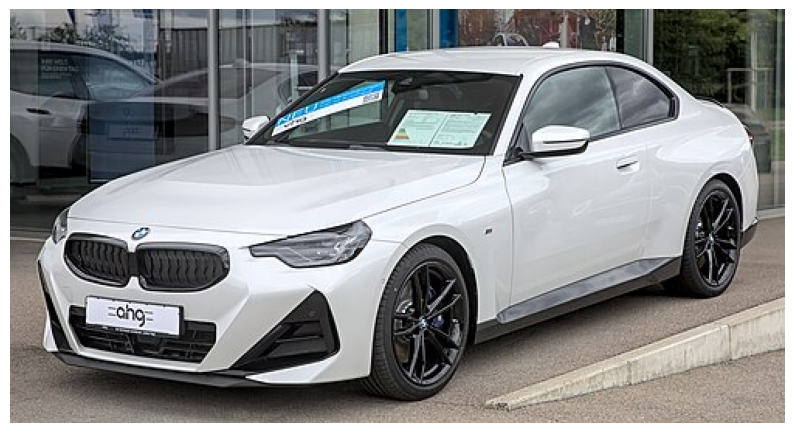

In [ ]:
from google.colab import files
import io

uploaded_files = files.upload()

uploaded_filename = next(
    iter(uploaded_files)
)

uploaded_image = Image.open(
    io.BytesIO(
        uploaded_files[uploaded_filename]
    )
).convert("RGB")

print("Uploaded file:", uploaded_filename)
print("Original image size:", uploaded_image.size)

plt.figure(figsize=(10, 7))
plt.imshow(uploaded_image)
plt.axis("off")
plt.show()

In [ ]:
prediction = predict_car(
    uploaded_image,
    top_k=5,
)

print("Predicted make:", prediction["make"])
print("Predicted model:", prediction["model"])
print("Predicted year:", prediction["year"])

print(
    "Make confidence:",
    f'{prediction["make_confidence"]:.2%}',
)

print(
    "Class confidence:",
    f'{prediction["class_confidence"]:.2%}',
)

print("\nTop predictions:")

for position, item in enumerate(
    prediction["top_predictions"],
    start=1,
):
    print(
        f'{position}. '
        f'{item["class_name"]} — '
        f'{item["probability"]:.2%}'
    )

Predicted make: BMW
Predicted model: M3 Coupe
Predicted year: 2012
Make confidence: 29.28%
Class confidence: 21.87%

Top predictions:
1. BMW M3 Coupe 2012 — 21.87%
2. Acura TL Sedan 2012 — 19.36%
3. Audi S4 Sedan 2012 — 8.57%
4. Audi TT Hatchback 2011 — 7.97%
5. Porsche Panamera Sedan 2012 — 5.15%


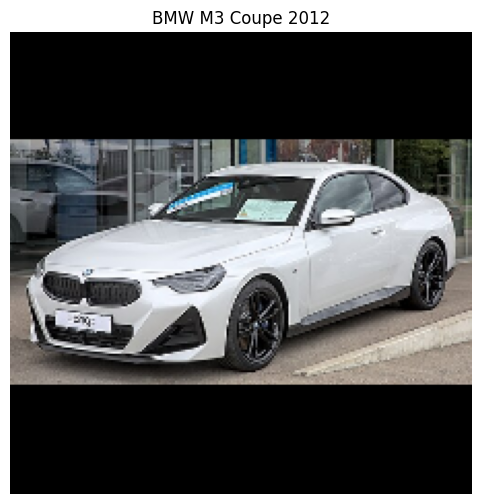

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    prediction["prepared_image"]
    .numpy()
    .astype("uint8")
)

plt.title(
    f'{prediction["make"]} '
    f'{prediction["model"]} '
    f'{prediction["year"]}'
)

plt.axis("off")
plt.show()

In [ ]:
validation_probabilities = final_model.predict(
    validation_dataset,
    verbose=1,
)

validation_true_indices = (
    validation_df["class_index"]
    .to_numpy()
)

validation_predicted_indices = np.argmax(
    validation_probabilities,
    axis=1,
)

validation_confidences = np.max(
    validation_probabilities,
    axis=1,
)

validation_correct = (
    validation_predicted_indices ==
    validation_true_indices
)

print(
    "Validation accuracy:",
    validation_correct.mean(),
)

print(
    "Average confidence:",
    validation_confidences.mean(),
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step
Validation accuracy: 0.585995085995086
Average confidence: 0.6715724


In [ ]:
confidence_analysis_df = pd.DataFrame({
    "confidence": validation_confidences,
    "correct": validation_correct,
})

confidence_analysis_df["confidence_bin"] = pd.cut(
    confidence_analysis_df["confidence"],
    bins=[
        0.0,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
    ],
    include_lowest=True,
)

confidence_bins = (
    confidence_analysis_df
    .groupby(
        "confidence_bin",
        observed=False,
    )
    .agg(
        samples=("correct", "size"),
        accuracy=("correct", "mean"),
        average_confidence=(
            "confidence",
            "mean",
        ),
    )
    .reset_index()
)

confidence_bins["accuracy_percent"] = (
    confidence_bins["accuracy"] * 100
).round(2)

display(confidence_bins)

,confidence_bin,samples,accuracy,average_confidence,accuracy_percent
0,"(-0.001, 0.1]",1,0.000000,0.099679,0.00
1,"(0.1, 0.2]",21,0.095238,0.160758,9.52
2,"(0.2, 0.3]",68,0.191176,0.253729,19.12
3,"(0.3, 0.4]",77,0.181818,0.353621,18.18
4,"(0.4, 0.5]",90,0.444444,0.450814,44.44
5,"(0.5, 0.6]",76,0.407895,0.552308,40.79
6,"(0.6, 0.7]",74,0.527027,0.651839,52.70
7,"(0.7, 0.8]",73,0.684932,0.748027,68.49
8,"(0.8, 0.9]",86,0.720930,0.852778,72.09
9,"(0.9, 1.0]",248,0.911290,0.967630,91.13


In [ ]:
threshold_rows = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    accepted = (
        validation_confidences >= threshold
    )

    accepted_count = int(accepted.sum())

    if accepted_count == 0:
        continue

    threshold_rows.append({
        "threshold": round(
            float(threshold),
            2,
        ),
        "accepted_samples": accepted_count,
        "coverage": accepted.mean(),
        "accepted_accuracy": (
            validation_correct[accepted].mean()
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df["coverage_percent"] = (
    threshold_df["coverage"] * 100
).round(2)

threshold_df["accepted_accuracy_percent"] = (
    threshold_df["accepted_accuracy"] * 100
).round(2)

display(threshold_df)

,threshold,accepted_samples,coverage,accepted_accuracy,coverage_percent,accepted_accuracy_percent
0,0.20,792,0.972973,0.599747,97.30,59.97
1,0.25,762,0.936118,0.614173,93.61,61.42
2,0.30,724,0.889435,0.638122,88.94,63.81
3,0.35,688,0.845209,0.662791,84.52,66.28
4,0.40,647,0.794840,0.692427,79.48,69.24
5,0.45,603,0.740786,0.711443,74.08,71.14
6,0.50,557,0.684275,0.732496,68.43,73.25
7,0.55,522,0.641278,0.756705,64.13,75.67
8,0.60,481,0.590909,0.783784,59.09,78.38
9,0.65,447,0.549140,0.807606,54.91,80.76


In [ ]:
sorted_validation_probabilities = np.sort(
    validation_probabilities,
    axis=1,
)

validation_top1 = (
    sorted_validation_probabilities[:, -1]
)

validation_top2 = (
    sorted_validation_probabilities[:, -2]
)

validation_margins = (
    validation_top1 -
    validation_top2
)

print(
    "Average top-1/top-2 margin:",
    validation_margins.mean(),
)

print(
    "Median top-1/top-2 margin:",
    np.median(validation_margins),
)

Average top-1/top-2 margin: 0.54241616
Median top-1/top-2 margin: 0.5547186


In [ ]:
CLASS_CONFIDENCE_THRESHOLD = 0.50
CLASS_MARGIN_THRESHOLD = 0.10

In [ ]:
def predict_car(pil_image, top_k=5):
    prepared_image = prepare_uploaded_image(
        pil_image
    )

    probabilities = final_model.predict(
        prepared_image[None, ...],
        verbose=0,
    )[0]

    sorted_indices = np.argsort(
        probabilities
    )[::-1]

    best_class_index = int(
        sorted_indices[0]
    )

    second_class_index = int(
        sorted_indices[1]
    )

    class_confidence = float(
        probabilities[best_class_index]
    )

    class_margin = float(
        probabilities[best_class_index]
        - probabilities[second_class_index]
    )

    # Aggregate probabilities by make.
    aggregated_make_probabilities = np.zeros(
        len(unique_make_names),
        dtype=np.float32,
    )

    for class_index, make in enumerate(
        class_make_names
    ):
        make_index = make_to_index[make]

        aggregated_make_probabilities[
            make_index
        ] += probabilities[class_index]

    best_make_index = int(
        np.argmax(
            aggregated_make_probabilities
        )
    )

    predicted_make = unique_make_names[
        best_make_index
    ]

    make_confidence = float(
        aggregated_make_probabilities[
            best_make_index
        ]
    )

    # Select the best class inside predicted make.
    make_class_indices = np.where(
        class_make_names == predicted_make
    )[0]

    consistent_class_index = int(
        make_class_indices[
            np.argmax(
                probabilities[
                    make_class_indices
                ]
            )
        ]
    )

    parsed_prediction = class_lookup.loc[
        consistent_class_index
    ]

    accepted = (
        class_confidence
        >= CLASS_CONFIDENCE_THRESHOLD
        and class_margin
        >= CLASS_MARGIN_THRESHOLD
    )

    top_predictions = []

    for class_index in sorted_indices[:top_k]:
        top_predictions.append({
            "class_name": (
                class_names[class_index]
            ),
            "probability": float(
                probabilities[class_index]
            ),
        })

    if accepted:
        predicted_model = parsed_prediction[
            "model"
        ]

        predicted_year = int(
            parsed_prediction["year"]
        )
    else:
        predicted_model = (
            "Unknown / unsupported"
        )
        predicted_year = None

    return {
        "prepared_image": prepared_image,
        "accepted": accepted,
        "make": predicted_make,
        "make_confidence": make_confidence,
        "model": predicted_model,
        "year": predicted_year,
        "class_confidence": class_confidence,
        "class_margin": class_margin,
        "nearest_known_class": (
            class_names[best_class_index]
        ),
        "top_predictions": top_predictions,
    }

In [ ]:
prediction = predict_car(
    uploaded_image,
    top_k=5,
)

print("Prediction accepted:", prediction["accepted"])
print("Predicted make:", prediction["make"])
print("Predicted model:", prediction["model"])
print("Predicted year:", prediction["year"])

print(
    "Make confidence:",
    f'{prediction["make_confidence"]:.2%}',
)

print(
    "Class confidence:",
    f'{prediction["class_confidence"]:.2%}',
)

print(
    "Top-1/top-2 margin:",
    f'{prediction["class_margin"]:.2%}',
)

print(
    "Nearest known class:",
    prediction["nearest_known_class"],
)

Prediction accepted: False
Predicted make: BMW
Predicted model: Unknown / unsupported
Predicted year: None
Make confidence: 29.28%
Class confidence: 21.87%
Top-1/top-2 margin: 2.51%
Nearest known class: BMW M3 Coupe 2012


In [ ]:
validation_sorted_probabilities = np.sort(
    validation_probabilities,
    axis=1,
)

validation_top1_confidences = (
    validation_sorted_probabilities[:, -1]
)

validation_top2_confidences = (
    validation_sorted_probabilities[:, -2]
)

validation_prediction_margins = (
    validation_top1_confidences
    - validation_top2_confidences
)

validation_accepted = (
    (
        validation_top1_confidences
        >= CLASS_CONFIDENCE_THRESHOLD
    )
    &
    (
        validation_prediction_margins
        >= CLASS_MARGIN_THRESHOLD
    )
)

print(
    "Accepted samples:",
    validation_accepted.sum(),
)

print(
    "Coverage:",
    validation_accepted.mean(),
)

print(
    "Accuracy among accepted:",
    validation_correct[
        validation_accepted
    ].mean(),
)

Accepted samples: 554
Coverage: 0.6805896805896806
Accuracy among accepted: 0.7328519855595668


In [ ]:
import json
from pathlib import Path

FINAL_MODEL_PATH = (
    ARTIFACTS_DIR /
    "car_classifier_final.keras"
)

# final_model был загружен до второго этапа,
# поэтому загружаем лучший stage 2 checkpoint.
final_model = tf.keras.models.load_model(
    ARTIFACTS_DIR /
    "best_fine_tuned_stage2.keras"
)

final_model.save(FINAL_MODEL_PATH)

inference_config = {
    "image_height": IMAGE_SIZE[0],
    "image_width": IMAGE_SIZE[1],
    "number_of_classes": len(class_names),
    "class_confidence_threshold": (
        CLASS_CONFIDENCE_THRESHOLD
    ),
    "class_margin_threshold": (
        CLASS_MARGIN_THRESHOLD
    ),
    "test_top1_accuracy": (
        0.5349693251533743
    ),
    "test_top5_accuracy": (
        0.8294478527607362
    ),
    "validation_accepted_coverage": float(
        validation_accepted.mean()
    ),
    "validation_accepted_accuracy": float(
        validation_correct[
            validation_accepted
        ].mean()
    ),
}

with open(
    ARTIFACTS_DIR / "inference_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        inference_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

parsed_classes.to_csv(
    ARTIFACTS_DIR / "class_metadata.csv",
    index=False,
)

print("Final model:", FINAL_MODEL_PATH)
print("Config:", ARTIFACTS_DIR / "inference_config.json")
print("Class metadata:", ARTIFACTS_DIR / "class_metadata.csv")

Final model: artifacts/car_classifier_final.keras
Config: artifacts/inference_config.json
Class metadata: artifacts/class_metadata.csv


In [ ]:
reloaded_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

reloaded_predictions = reloaded_model.predict(
    batch_images[:2],
    verbose=0,
)

original_predictions = final_model.predict(
    batch_images[:2],
    verbose=0,
)

maximum_difference = np.max(
    np.abs(
        reloaded_predictions -
        original_predictions
    )
)

print(
    "Maximum prediction difference:",
    maximum_difference,
)

assert maximum_difference < 1e-5

print("Model reload check passed.")

Maximum prediction difference: 0.0
Model reload check passed.


In [ ]:
import shutil

archive_path = shutil.make_archive(
    base_name="car_classifier_artifacts",
    format="zip",
    root_dir=ARTIFACTS_DIR,
)

archive_size_mb = (
    Path(archive_path).stat().st_size /
    1024**2
)

print("Archive path:", archive_path)
print(
    "Archive size:",
    round(archive_size_mb, 2),
    "MB",
)

Archive path: /content/car_classifier_artifacts.zip
Archive size: 138.02 MB


In [ ]:
from google.colab import files

files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Classification END


In [ ]:
import kagglehub
from pathlib import Path

price_dataset_path = kagglehub.dataset_download(
    "andreinovikov/used-cars-dataset"
)

PRICE_DATASET_DIR = Path(
    price_dataset_path
)

print(
    "Price dataset directory:",
    PRICE_DATASET_DIR,
)

print(
    "Directory exists:",
    PRICE_DATASET_DIR.exists(),
)

100%|██████████| 23.1M/23.1M [00:00<00:00, 65.4MB/s]

Extracting files...


Price dataset directory: /root/.cache/kagglehub/datasets/andreinovikov/used-cars-dataset/versions/1
Directory exists: True


In [ ]:
print("Dataset files:")

for file_path in sorted(
    PRICE_DATASET_DIR.rglob("*")
):
    if not file_path.is_file():
        continue

    size_mb = (
        file_path.stat().st_size /
        1024**2
    )

    print(
        file_path.relative_to(
            PRICE_DATASET_DIR
        ),
        "-",
        round(size_mb, 2),
        "MB",
    )

Dataset files:
cars.csv - 138.49 MB


In [ ]:
price_csv_paths = sorted(
    PRICE_DATASET_DIR.rglob("*.csv")
)

print(
    "Number of CSV files:",
    len(price_csv_paths),
)

for index, csv_path in enumerate(
    price_csv_paths
):
    print(
        index,
        csv_path.relative_to(
            PRICE_DATASET_DIR
        ),
    )

Number of CSV files: 1
0 cars.csv


In [ ]:
import pandas as pd

PRICE_CSV_PATH = price_csv_paths[0]

price_preview_df = pd.read_csv(
    PRICE_CSV_PATH,
    nrows=10,
)

print("CSV path:", PRICE_CSV_PATH)

print("\nColumns:")
print(price_preview_df.columns.tolist())

print("\nShape of preview:")
print(price_preview_df.shape)

print("\nData types:")
print(price_preview_df.dtypes)

print("\nFirst rows:")
display(price_preview_df.head())

CSV path: /root/.cache/kagglehub/datasets/andreinovikov/used-cars-dataset/versions/1/cars.csv

Columns:
['manufacturer', 'model', 'year', 'mileage', 'engine', 'transmission', 'drivetrain', 'fuel_type', 'mpg', 'exterior_color', 'interior_color', 'accidents_or_damage', 'one_owner', 'personal_use_only', 'seller_name', 'seller_rating', 'driver_rating', 'driver_reviews_num', 'price_drop', 'price']

Shape of preview:
(10, 20)

Data types:
manufacturer            object
model                   object
year                     int64
mileage                float64
engine                  object
transmission            object
drivetrain              object
fuel_type               object
mpg                     object
exterior_color          object
interior_color          object
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
seller_name             object
seller_rating          float64
driver_rating          float64
driver_reviews_num     float64
price

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [ ]:
with open(
    PRICE_CSV_PATH,
    "rb",
) as file:
    number_of_lines = sum(
        1 for _ in file
    )

print(
    "Approximate number of data rows:",
    number_of_lines - 1,
)

Approximate number of data rows: 762092


In [ ]:
PRICE_COLUMNS = [
    "manufacturer",
    "model",
    "year",
    "mileage",
    "accidents_or_damage",
    "one_owner",
    "personal_use_only",
    "price",
]

price_df = pd.read_csv(
    PRICE_CSV_PATH,
    usecols=PRICE_COLUMNS,
)

print("Dataset shape:", price_df.shape)

memory_mb = (
    price_df.memory_usage(
        deep=True
    ).sum()
    / 1024**2
)

print(
    "Memory usage:",
    round(memory_mb, 2),
    "MB",
)

print("\nData types:")
print(price_df.dtypes)

Dataset shape: (762091, 8)
Memory usage: 120.84 MB

Data types:
manufacturer            object
model                   object
year                     int64
mileage                float64
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
price                  float64
dtype: object


In [ ]:
missing_statistics = pd.DataFrame({
    "missing_count": price_df.isna().sum(),
    "missing_percent": (
        price_df.isna().mean() * 100
    ).round(2),
})

display(
    missing_statistics.sort_values(
        "missing_percent",
        ascending=False,
    )
)

,missing_count,missing_percent
one_owner,31483,4.13
personal_use_only,24852,3.26
accidents_or_damage,24212,3.18
mileage,506,0.07
year,0,0.00
model,0,0.00
manufacturer,0,0.00
price,0,0.00


In [ ]:
numeric_columns = [
    "year",
    "mileage",
    "price",
]

display(
    price_df[numeric_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,762091.0,2017.791398,5.110532e+00,1915.0,2001.0,2010.0,2016.0,2019.0,2021.0,2022.0,2023.00,2.024000e+03
mileage,761585.0,55781.692701,4.355788e+04,0.0,250.0,4643.0,23287.0,45596.0,78365.0,138774.0,193606.48,1.119067e+06
price,762091.0,36488.983085,1.984183e+06,1.0,5999.0,9995.0,19583.0,27989.0,39488.0,68846.0,109995.00,1.000000e+09


In [ ]:
print(
    "Unique manufacturers:",
    price_df["manufacturer"].nunique(
        dropna=True
    ),
)

print(
    "Unique models:",
    price_df["model"].nunique(
        dropna=True
    ),
)

print("\nMost frequent manufacturers:")

display(
    price_df["manufacturer"]
    .value_counts(
        dropna=False
    )
    .head(20)
    .rename_axis("manufacturer")
    .reset_index(name="count")
)

Unique manufacturers: 30
Unique models: 12187

Most frequent manufacturers:


,manufacturer,count
0,Ford,79526
1,Toyota,59535
2,Chevrolet,56043
3,Nissan,48529
4,Jeep,41665
5,Mercedes-Benz,40824
6,Honda,37612
7,BMW,37570
8,Kia,35063
9,GMC,29563


In [ ]:
exact_duplicate_count = int(
    price_df.duplicated().sum()
)

listing_duplicate_count = int(
    price_df.duplicated(
        subset=[
            "manufacturer",
            "model",
            "year",
            "mileage",
            "price",
        ]
    ).sum()
)

print(
    "Exact duplicate rows:",
    exact_duplicate_count,
)

print(
    "Duplicate vehicle-price rows:",
    listing_duplicate_count,
)

Exact duplicate rows: 9479
Duplicate vehicle-price rows: 9607


In [ ]:
import re


def normalize_category(value):
    if pd.isna(value):
        return None

    normalized = str(value).lower().strip()

    normalized = re.sub(
        r"[^a-z0-9]+",
        " ",
        normalized,
    )

    normalized = re.sub(
        r"\s+",
        " ",
        normalized,
    )

    return normalized.strip()


price_df["manufacturer_normalized"] = (
    price_df["manufacturer"]
    .map(normalize_category)
)

parsed_classes["make_normalized"] = (
    parsed_classes["make"]
    .map(normalize_category)
)

price_manufacturers = set(
    price_df[
        "manufacturer_normalized"
    ].dropna()
)

classifier_manufacturers = set(
    parsed_classes[
        "make_normalized"
    ].dropna()
)

common_manufacturers = sorted(
    classifier_manufacturers
    & price_manufacturers
)

missing_price_manufacturers = sorted(
    classifier_manufacturers
    - price_manufacturers
)

print(
    "Classifier manufacturers:",
    len(classifier_manufacturers),
)

print(
    "Common manufacturers:",
    len(common_manufacturers),
)

print(
    "Coverage:",
    len(common_manufacturers)
    / len(classifier_manufacturers),
)

print(
    "\nClassifier makes missing from price dataset:"
)

print(missing_price_manufacturers)

Classifier manufacturers: 49
Common manufacturers: 27
Coverage: 0.5510204081632653

Classifier makes missing from price dataset:
['am general', 'aston martin', 'bentley', 'bugatti', 'daewoo', 'eagle', 'ferrari', 'fiat', 'fisker', 'geo', 'hummer', 'isuzu', 'lamborghini', 'maybach', 'mclaren', 'mini', 'plymouth', 'rolls royce', 'scion', 'smart', 'spyker', 'suzuki']


In [ ]:
quality_checks = {
    "price_below_1000": (
        price_df["price"] < 1000
    ).sum(),

    "price_above_300000": (
        price_df["price"] > 300000
    ).sum(),

    "year_before_1990": (
        price_df["year"] < 1990
    ).sum(),

    "year_after_2024": (
        price_df["year"] > 2024
    ).sum(),

    "negative_mileage": (
        price_df["mileage"] < 0
    ).sum(),

    "mileage_above_300000": (
        price_df["mileage"] > 300000
    ).sum(),

    "missing_mileage": (
        price_df["mileage"].isna()
    ).sum(),

    "duplicate_vehicle_price_rows": (
        price_df.duplicated(
            subset=[
                "manufacturer",
                "model",
                "year",
                "mileage",
                "price",
            ]
        ).sum()
    ),
}

for check_name, count in quality_checks.items():
    print(f"{check_name}: {count}")

price_below_1000: 39
price_above_300000: 244
year_before_1990: 3103
year_after_2024: 0
negative_mileage: 0
mileage_above_300000: 390
missing_mileage: 506
duplicate_vehicle_price_rows: 9607


In [ ]:
price_clean_df = price_df.copy()

initial_row_count = len(
    price_clean_df
)

price_clean_df = price_clean_df[
    price_clean_df["price"].between(
        1000,
        300000,
    )
]

price_clean_df = price_clean_df[
    price_clean_df["year"].between(
        1990,
        2024,
    )
]

valid_mileage = (
    price_clean_df["mileage"].isna()
    |
    price_clean_df["mileage"].between(
        0,
        300000,
    )
)

price_clean_df = price_clean_df[
    valid_mileage
]

price_clean_df = (
    price_clean_df
    .drop_duplicates(
        subset=[
            "manufacturer",
            "model",
            "year",
            "mileage",
            "price",
        ]
    )
    .reset_index(drop=True)
)

price_clean_df[
    "manufacturer_normalized"
] = price_clean_df[
    "manufacturer"
].map(normalize_category)

price_clean_df[
    "model_normalized"
] = price_clean_df[
    "model"
].map(normalize_category)

removed_row_count = (
    initial_row_count -
    len(price_clean_df)
)

print("Initial rows:", initial_row_count)
print("Clean rows:", len(price_clean_df))
print("Removed rows:", removed_row_count)

print(
    "Removed percent:",
    round(
        removed_row_count
        / initial_row_count
        * 100,
        2,
    ),
)

Initial rows: 762091
Clean rows: 748779
Removed rows: 13312
Removed percent: 1.75


In [ ]:
display(
    price_clean_df[
        ["year", "mileage", "price"]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,748779.0,2017.988922,4.034439,1990.0,2003.0,2010.0,2016.0,2019.0,2021.0,2022.0,2023.00,2024.0
mileage,748337.0,55696.342073,42869.626637,0.0,352.0,4810.0,23380.0,45628.0,78334.0,138406.2,191993.88,300000.0
price,748779.0,32319.176828,21132.622041,1000.0,5999.0,9998.0,19595.0,27988.0,39375.0,68000.0,108927.38,300000.0


In [ ]:
supported_classifier_classes = (
    parsed_classes[
        "make_normalized"
    ].isin(
        set(
            price_clean_df[
                "manufacturer_normalized"
            ]
        )
    )
)

print(
    "Supported classifier classes:",
    supported_classifier_classes.sum(),
)

print(
    "Total classifier classes:",
    len(parsed_classes),
)

print(
    "Class coverage:",
    supported_classifier_classes.mean(),
)

test_make_supported = (
    results_df["predicted_make"]
    .map(normalize_category)
    .isin(
        set(
            price_clean_df[
                "manufacturer_normalized"
            ]
        )
    )
)

print(
    "Price coverage for test predictions:",
    test_make_supported.mean(),
)

Supported classifier classes: 151
Total classifier classes: 196
Class coverage: 0.7704081632653061
Price coverage for test predictions: 0.7742331288343558


In [ ]:
for make in [
    "BMW",
    "Audi",
    "Acura",
    "Ford",
]:
    print(f"\n--- {make}: classifier models ---")

    classifier_models = (
        parsed_classes.loc[
            parsed_classes["make"] == make,
            "model",
        ]
        .drop_duplicates()
        .sort_values()
    )

    print(
        classifier_models
        .head(15)
        .tolist()
    )

    print(f"\n--- {make}: price models ---")

    price_models = (
        price_clean_df.loc[
            price_clean_df[
                "manufacturer"
            ].str.lower()
            == make.lower(),
            "model",
        ]
        .drop_duplicates()
        .sort_values()
    )

    print(
        price_models
        .head(30)
        .tolist()
    )


--- BMW: classifier models ---
['1 Series Convertible', '1 Series Coupe', '3 Series Sedan', '3 Series Wagon', '6 Series Convertible', 'ActiveHybrid 5 Sedan', 'M3 Coupe', 'M5 Sedan', 'M6 Convertible', 'X3 SUV', 'X5 SUV', 'X6 SUV', 'Z4 Convertible']

--- BMW: price models ---
['128 128i', '128 128i Convertible 2D', '128 I', '128 i', '135 135i', '135 135i 2dr Convertible', '135 135i Coupe 2D', '135 135is', '135 i', '135 is', '228 228i', '228 Gran Coupe', '228 Gran Coupe 228i', '228 Gran Coupe 228i sDrive Gran Coupe', '228 Gran Coupe 228i xDrive', '228 Gran Coupe i xDrive', '228 i', '228 i xDrive', '228 xDrive', '230', '230 230i', '230 230i 2dr Coupe', '230 230i Convertible 2D', '230 230i xDrive', '230 i', '230 i xDrive', '230 xDrive', '318 i', '318 iC', '318 iS']

--- Audi: classifier models ---
['100 Sedan', '100 Wagon', 'A5 Coupe', 'R8 Coupe', 'RS 4 Convertible', 'S4 Sedan', 'S5 Convertible', 'S5 Coupe', 'S6 Sedan', 'TT Hatchback', 'TT RS Coupe', 'TTS Coupe', 'V8 Sedan']

--- Audi: pri

In [ ]:
BODY_SUFFIX_PATTERN = re.compile(
    r"\s+("
    r"crew cab|"
    r"regular cab|"
    r"extended cab|"
    r"quad cab|"
    r"supercab|"
    r"convertible|"
    r"hatchback|"
    r"minivan|"
    r"roadster|"
    r"sedan|"
    r"coupe|"
    r"wagon|"
    r"suv|"
    r"van"
    r")$",
    flags=re.IGNORECASE,
)


def extract_classifier_model_family(
    model_name
):
    family = BODY_SUFFIX_PATTERN.sub(
        "",
        str(model_name).strip(),
    )

    return normalize_category(family)


parsed_classes["model_family"] = (
    parsed_classes["model"]
    .map(
        extract_classifier_model_family
    )
)

print(
    "Unique classifier model families:",
    parsed_classes[
        ["make_normalized", "model_family"]
    ]
    .drop_duplicates()
    .shape[0],
)

display(
    parsed_classes[
        [
            "make",
            "model",
            "model_family",
            "year",
        ]
    ].head(30)
)

Unique classifier model families: 176


,make,model,model_family,year
0,AM General,Hummer SUV,hummer,2000
1,Acura,RL Sedan,rl,2012
2,Acura,TL Sedan,tl,2012
3,Acura,TL Type-S,tl type s,2008
4,Acura,TSX Sedan,tsx,2012
5,Acura,Integra Type R,integra type r,2001
6,Acura,ZDX Hatchback,zdx,2012
7,Aston Martin,V8 Vantage Convertible,v8 vantage,2012
8,Aston Martin,V8 Vantage Coupe,v8 vantage,2012
9,Aston Martin,Virage Convertible,virage,2012


In [ ]:
make_to_model_families = {}

for make, group in parsed_classes.groupby(
    "make_normalized"
):
    families = (
        group["model_family"]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    # Сначала проверяем длинные варианты,
    # чтобы TT RS выбирался раньше TT.
    make_to_model_families[make] = sorted(
        families,
        key=len,
        reverse=True,
    )

print(
    "Manufacturers in mapping:",
    len(make_to_model_families),
)

print(
    "BMW model families:",
    make_to_model_families.get(
        "bmw",
        [],
    ),
)

print(
    "Audi model families:",
    make_to_model_families.get(
        "audi",
        [],
    ),
)

Manufacturers in mapping: 49
BMW model families: ['activehybrid 5', '1 series', '3 series', '6 series', 'x5', 'x6', 'm3', 'm5', 'm6', 'x3', 'z4']
Audi model families: ['tt rs', 'rs 4', 'tts', '100', 'a5', 'r8', 'v8', 'tt', 's6', 's5', 's4']


In [ ]:
def match_price_model_family(
    manufacturer,
    model,
):
    make = normalize_category(
        manufacturer
    )

    normalized_model = normalize_category(
        model
    )

    if (
        make is None
        or normalized_model is None
    ):
        return None

    candidate_families = (
        make_to_model_families.get(
            make,
            [],
        )
    )

    for family in candidate_families:
        if (
            normalized_model == family
            or normalized_model.startswith(
                family + " "
            )
        ):
            return family

    return None


price_clean_df["matched_model_family"] = [
    match_price_model_family(
        manufacturer,
        model,
    )
    for manufacturer, model in zip(
        price_clean_df["manufacturer"],
        price_clean_df["model"],
    )
]

matched_rows = (
    price_clean_df[
        "matched_model_family"
    ].notna()
)

print(
    "Matched price rows:",
    matched_rows.sum(),
)

print(
    "Total clean price rows:",
    len(price_clean_df),
)

print(
    "Matched row coverage:",
    matched_rows.mean(),
)

Matched price rows: 204805
Total clean price rows: 748779
Matched row coverage: 0.2735186216493785


In [ ]:
family_price_counts = (
    price_clean_df.loc[
        matched_rows
    ]
    .groupby([
        "manufacturer_normalized",
        "matched_model_family",
    ])
    .size()
    .reset_index(name="listing_count")
    .sort_values("listing_count")
)

classifier_families = (
    parsed_classes[
        [
            "make_normalized",
            "model_family",
        ]
    ]
    .drop_duplicates()
)

family_coverage_df = (
    classifier_families
    .merge(
        family_price_counts,
        how="left",
        left_on=[
            "make_normalized",
            "model_family",
        ],
        right_on=[
            "manufacturer_normalized",
            "matched_model_family",
        ],
    )
)

family_coverage_df["listing_count"] = (
    family_coverage_df["listing_count"]
    .fillna(0)
    .astype(int)
)

print(
    "Total classifier families:",
    len(family_coverage_df),
)

print(
    "Families with at least 1 listing:",
    (
        family_coverage_df[
            "listing_count"
        ] >= 1
    ).sum(),
)

print(
    "Families with at least 20 listings:",
    (
        family_coverage_df[
            "listing_count"
        ] >= 20
    ).sum(),
)

print(
    "Families with at least 100 listings:",
    (
        family_coverage_df[
            "listing_count"
        ] >= 100
    ).sum(),
)

print("\nLeast covered families:")

display(
    family_coverage_df
    .sort_values("listing_count")
    .head(25)
)

print("\nMost covered families:")

display(
    family_coverage_df
    .sort_values(
        "listing_count",
        ascending=False,
    )
    .head(25)
)

Total classifier families: 176
Families with at least 1 listing: 115
Families with at least 20 listings: 98
Families with at least 100 listings: 84

Least covered families:


,make_normalized,model_family,manufacturer_normalized,matched_model_family,listing_count
0,am general,hummer,NaN,NaN,0
7,aston martin,v8 vantage,NaN,NaN,0
13,audi,v8,NaN,NaN,0
8,aston martin,virage,NaN,NaN,0
14,audi,100,NaN,NaN,0
21,bmw,1 series,NaN,NaN,0
23,bmw,6 series,NaN,NaN,0
22,bmw,3 series,NaN,NaN,0
31,bentley,continental supersports conv,NaN,NaN,0
52,chevrolet,tahoe hybrid,NaN,NaN,0



Most covered families:


,make_normalized,model_family,manufacturer_normalized,matched_model_family,listing_count
128,jeep,wrangler,jeep,wrangler,11711
136,land rover,range rover,land rover,range rover,8530
130,jeep,grand cherokee,jeep,grand cherokee,7454
168,toyota,corolla,toyota,corolla,6479
167,toyota,camry,toyota,camry,6276
92,ford,mustang,ford,mustang,6080
111,honda,accord,honda,accord,6049
98,ford,f 150,ford,f 150,5350
105,gmc,acadia,gmc,acadia,5070
131,jeep,compass,jeep,compass,4961


In [ ]:
MIN_FAMILY_LISTINGS = 20

family_counts = (
    price_clean_df
    .groupby([
        "manufacturer_normalized",
        "matched_model_family",
    ])
    .size()
)

supported_family_keys = set(
    family_counts[
        family_counts >= MIN_FAMILY_LISTINGS
    ].index
)

price_model_df = price_clean_df[
    price_clean_df[
        "matched_model_family"
    ].notna()
].copy()

price_model_df["family_key"] = list(
    zip(
        price_model_df[
            "manufacturer_normalized"
        ],
        price_model_df[
            "matched_model_family"
        ],
    )
)

price_model_df = price_model_df[
    price_model_df["family_key"].isin(
        supported_family_keys
    )
].reset_index(drop=True)

price_model_df["log_price"] = np.log1p(
    price_model_df["price"]
)

print(
    "Price model rows:",
    len(price_model_df),
)

print(
    "Supported families:",
    price_model_df[
        "family_key"
    ].nunique(),
)

print(
    "Price median:",
    price_model_df["price"].median(),
)

print(
    "Price mean:",
    price_model_df["price"].mean(),
)

Price model rows: 204675
Supported families: 98
Price median: 27399.0
Price mean: 31070.593404177354


In [ ]:
from sklearn.model_selection import (
    train_test_split,
)

price_train_df, price_temporary_df = (
    train_test_split(
        price_model_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=price_model_df[
            "family_key"
        ],
    )
)

price_validation_df, price_test_df = (
    train_test_split(
        price_temporary_df,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=price_temporary_df[
            "family_key"
        ],
    )
)

price_train_df = (
    price_train_df.reset_index(drop=True)
)

price_validation_df = (
    price_validation_df.reset_index(
        drop=True
    )
)

price_test_df = (
    price_test_df.reset_index(drop=True)
)

print("Train size:", len(price_train_df))
print(
    "Validation size:",
    len(price_validation_df),
)
print("Test size:", len(price_test_df))

print("\nUnique families:")
print(
    "Train:",
    price_train_df["family_key"].nunique(),
)
print(
    "Validation:",
    price_validation_df[
        "family_key"
    ].nunique(),
)
print(
    "Test:",
    price_test_df[
        "family_key"
    ].nunique(),
)

Train size: 163740
Validation size: 20467
Test size: 20468

Unique families:
Train: 98
Validation: 98
Test: 98


In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

PRICE_FEATURES = [
    "manufacturer_normalized",
    "matched_model_family",
    "year",
]

CATEGORICAL_FEATURES = [
    "manufacturer_normalized",
    "matched_model_family",
]

X_price_train = price_train_df[
    PRICE_FEATURES
]

y_price_train = price_train_df[
    "log_price"
]

X_price_validation = price_validation_df[
    PRICE_FEATURES
]

y_price_validation = price_validation_df[
    "log_price"
]

print("Train features shape:", X_price_train.shape)
print(
    "Validation features shape:",
    X_price_validation.shape,
)

display(X_price_train.head())

Train features shape: (163740, 3)
Validation features shape: (20467, 3)


,manufacturer_normalized,matched_model_family,year
0,chevrolet,impala,2014
1,dodge,durango,2013
2,jeep,wrangler,2021
3,hyundai,santa fe,2023
4,jeep,grand cherokee,2012


In [ ]:
price_model = CatBoostRegressor(
    iterations=1200,
    depth=8,
    learning_rate=0.08,
    loss_function="RMSE",
    l2_leaf_reg=5.0,
    random_strength=0.5,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False,
    thread_count=-1,
)

price_model.fit(
    X_price_train,
    y_price_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(
        X_price_validation,
        y_price_validation,
    ),
    early_stopping_rounds=100,
    use_best_model=True,
)

0:	learn: 0.5547879	test: 0.5535582	best: 0.5535582 (0)	total: 127ms	remaining: 2m 32s
100:	learn: 0.2275475	test: 0.2264885	best: 0.2264885 (100)	total: 13.6s	remaining: 2m 27s
200:	learn: 0.2223309	test: 0.2218945	best: 0.2218945 (200)	total: 32s	remaining: 2m 38s
300:	learn: 0.2201808	test: 0.2204478	best: 0.2204421 (298)	total: 47.3s	remaining: 2m 21s
400:	learn: 0.2190319	test: 0.2198287	best: 0.2198287 (400)	total: 54.2s	remaining: 1m 48s
500:	learn: 0.2181088	test: 0.2196276	best: 0.2196276 (500)	total: 1m	remaining: 1m 24s
600:	learn: 0.2173615	test: 0.2193839	best: 0.2193833 (599)	total: 1m 8s	remaining: 1m 7s
700:	learn: 0.2168545	test: 0.2193029	best: 0.2192987 (699)	total: 1m 15s	remaining: 53.8s
800:	learn: 0.2163893	test: 0.2192369	best: 0.2192369 (800)	total: 1m 21s	remaining: 40.7s
900:	learn: 0.2159275	test: 0.2190887	best: 0.2190831 (893)	total: 1m 29s	remaining: 29.6s
1000:	learn: 0.2155490	test: 0.2190714	best: 0.2190544 (977)	total: 1m 35s	remaining: 19s
1100:	lear

CatBoostRegressor(allow_writing_files=False, depth=8, iterations=1200, l2_leaf_reg=5.0, learning_rate=0.08, loss_function='RMSE', random_seed=42, random_strength=0.5, verbose=100)

In [ ]:
validation_log_predictions = (
    price_model.predict(
        X_price_validation
    )
)

validation_price_predictions = np.expm1(
    validation_log_predictions
)

validation_actual_prices = (
    price_validation_df[
        "price"
    ].to_numpy()
)

price_validation_metrics = {
    "MAE": mean_absolute_error(
        validation_actual_prices,
        validation_price_predictions,
    ),

    "Median AE": median_absolute_error(
        validation_actual_prices,
        validation_price_predictions,
    ),

    "MAPE": (
        mean_absolute_percentage_error(
            validation_actual_prices,
            validation_price_predictions,
        )
    ),

    "R2": r2_score(
        validation_actual_prices,
        validation_price_predictions,
    ),
}

print("Validation metrics:")

for metric_name, metric_value in (
    price_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Validation metrics:
MAE: 4734.9117
Median AE: 2915.5868
MAPE: 0.1586
R2: 0.7970


In [ ]:
global_price_median = (
    price_train_df["price"].median()
)

make_price_medians = (
    price_train_df
    .groupby(
        "manufacturer_normalized"
    )["price"]
    .median()
    .to_dict()
)

family_price_medians = (
    price_train_df
    .groupby([
        "manufacturer_normalized",
        "matched_model_family",
    ])["price"]
    .median()
    .to_dict()
)

family_year_price_medians = (
    price_train_df
    .groupby([
        "manufacturer_normalized",
        "matched_model_family",
        "year",
    ])["price"]
    .median()
    .to_dict()
)


def median_price_prediction(row):
    family_year_key = (
        row["manufacturer_normalized"],
        row["matched_model_family"],
        row["year"],
    )

    family_key = (
        row["manufacturer_normalized"],
        row["matched_model_family"],
    )

    if (
        family_year_key
        in family_year_price_medians
    ):
        return family_year_price_medians[
            family_year_key
        ]

    if family_key in family_price_medians:
        return family_price_medians[
            family_key
        ]

    make = row[
        "manufacturer_normalized"
    ]

    if make in make_price_medians:
        return make_price_medians[make]

    return global_price_median


median_validation_predictions = (
    price_validation_df.apply(
        median_price_prediction,
        axis=1,
    ).to_numpy()
)

print(
    "Global train price median:",
    global_price_median,
)

Global train price median: 27400.0


In [ ]:
def calculate_price_metrics(
    actual,
    predicted,
):
    return {
        "MAE": mean_absolute_error(
            actual,
            predicted,
        ),
        "Median AE": (
            median_absolute_error(
                actual,
                predicted,
            )
        ),
        "MAPE": (
            mean_absolute_percentage_error(
                actual,
                predicted,
            )
        ),
        "R2": r2_score(
            actual,
            predicted,
        ),
    }


median_metrics = calculate_price_metrics(
    validation_actual_prices,
    median_validation_predictions,
)

catboost_metrics = calculate_price_metrics(
    validation_actual_prices,
    validation_price_predictions,
)

comparison_df = pd.DataFrame([
    {
        "model": "Hierarchical median",
        **median_metrics,
    },
    {
        "model": "CatBoost",
        **catboost_metrics,
    },
])

comparison_df["MAPE percent"] = (
    comparison_df["MAPE"] * 100
).round(2)

display(comparison_df)

,model,MAE,Median AE,MAPE,R2,MAPE percent
0,Hierarchical median,4678.358724,2875.50000,0.157551,0.789584,15.76
1,CatBoost,4734.911653,2915.58683,0.158620,0.796981,15.86


In [ ]:
X_price_test = price_test_df[
    PRICE_FEATURES
]

test_actual_prices = (
    price_test_df["price"].to_numpy()
)

test_log_predictions = (
    price_model.predict(
        X_price_test
    )
)

test_price_predictions = np.expm1(
    test_log_predictions
)

price_test_metrics = calculate_price_metrics(
    test_actual_prices,
    test_price_predictions,
)

print("Final price test metrics:")

for metric_name, metric_value in (
    price_test_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Final price test metrics:
MAE: 4863.9978
Median AE: 2888.3773
MAPE: 0.1605
R2: 0.7785


In [ ]:
price_errors_df = pd.DataFrame({
    "actual_price": (
        test_actual_prices
    ),
    "predicted_price": (
        test_price_predictions
    ),
})

price_errors_df["absolute_error"] = np.abs(
    price_errors_df["actual_price"]
    - price_errors_df["predicted_price"]
)

price_errors_df["percentage_error"] = (
    price_errors_df["absolute_error"]
    / price_errors_df["actual_price"]
)

print("Absolute error percentiles:")

print(
    price_errors_df[
        "absolute_error"
    ].quantile([
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ])
)

print("\nPercentage error percentiles:")

print(
    price_errors_df[
        "percentage_error"
    ].quantile([
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ])
)

Absolute error percentiles:
0.25     1326.796121
0.50     2888.377261
0.75     5491.986450
0.90     9967.615659
0.95    15032.835186
0.99    35736.494963
Name: absolute_error, dtype: float64

Percentage error percentiles:
0.25    0.053850
0.50    0.114944
0.75    0.207881
0.90    0.338782
0.95    0.458303
0.99    0.799252
Name: percentage_error, dtype: float64


In [ ]:
def build_price_statistics(
    dataframe,
    group_columns,
    level_name,
):
    statistics = (
        dataframe
        .groupby(group_columns)["price"]
        .agg(
            median_price="median",
            lower_price=lambda values: (
                values.quantile(0.25)
            ),
            upper_price=lambda values: (
                values.quantile(0.75)
            ),
            listing_count="size",
        )
        .reset_index()
    )

    statistics["level"] = level_name

    return statistics


exact_price_stats = build_price_statistics(
    price_model_df,
    [
        "manufacturer_normalized",
        "matched_model_family",
        "year",
    ],
    "family_year",
)

family_price_stats = build_price_statistics(
    price_model_df,
    [
        "manufacturer_normalized",
        "matched_model_family",
    ],
    "family",
)

make_year_price_stats = build_price_statistics(
    price_clean_df,
    [
        "manufacturer_normalized",
        "year",
    ],
    "make_year",
)

make_price_stats = build_price_statistics(
    price_clean_df,
    [
        "manufacturer_normalized",
    ],
    "make",
)

print(
    "Family-year groups:",
    len(exact_price_stats),
)

print(
    "Family groups:",
    len(family_price_stats),
)

print(
    "Make-year groups:",
    len(make_year_price_stats),
)

print(
    "Make groups:",
    len(make_price_stats),
)

Family-year groups: 1674
Family groups: 98
Make-year groups: 928
Make groups: 30


In [ ]:
def first_matching_row(
    dataframe,
    mask,
    minimum_listings,
):
    matches = dataframe[
        mask
        &
        (
            dataframe["listing_count"]
            >= minimum_listings
        )
    ]

    if matches.empty:
        return None

    return matches.iloc[0]


def estimate_car_price(
    make,
    model_family,
    year,
):
    normalized_make = normalize_category(
        make
    )

    normalized_family = (
        extract_classifier_model_family(
            model_family
        )
    )

    # Level 1: same make, family and year.
    match = first_matching_row(
        exact_price_stats,
        (
            exact_price_stats[
                "manufacturer_normalized"
            ].eq(normalized_make)
            &
            exact_price_stats[
                "matched_model_family"
            ].eq(normalized_family)
            &
            exact_price_stats[
                "year"
            ].eq(int(year))
        ),
        minimum_listings=10,
    )

    # Level 2: same family, any year.
    if match is None:
        match = first_matching_row(
            family_price_stats,
            (
                family_price_stats[
                    "manufacturer_normalized"
                ].eq(normalized_make)
                &
                family_price_stats[
                    "matched_model_family"
                ].eq(normalized_family)
            ),
            minimum_listings=20,
        )

    # Level 3: same make and year.
    if match is None:
        match = first_matching_row(
            make_year_price_stats,
            (
                make_year_price_stats[
                    "manufacturer_normalized"
                ].eq(normalized_make)
                &
                make_year_price_stats[
                    "year"
                ].eq(int(year))
            ),
            minimum_listings=20,
        )

    # Level 4: same make, any year.
    if match is None:
        match = first_matching_row(
            make_price_stats,
            make_price_stats[
                "manufacturer_normalized"
            ].eq(normalized_make),
            minimum_listings=100,
        )

    if match is None:
        return {
            "available": False,
            "reason": "Unsupported make",
        }

    return {
        "available": True,
        "estimated_price": float(
            match["median_price"]
        ),
        "lower_price": float(
            match["lower_price"]
        ),
        "upper_price": float(
            match["upper_price"]
        ),
        "listing_count": int(
            match["listing_count"]
        ),
        "fallback_level": match["level"],
    }

In [ ]:
test_price_cases = [
    {
        "make": "BMW",
        "model": "M3 Coupe",
        "year": 2012,
    },
    {
        "make": "Toyota",
        "model": "Camry Sedan",
        "year": 2012,
    },
    {
        "make": "Audi",
        "model": "TT Hatchback",
        "year": 2011,
    },
    {
        "make": "Ferrari",
        "model": "458 Italia Convertible",
        "year": 2012,
    },
]

for case in test_price_cases:
    result = estimate_car_price(
        make=case["make"],
        model_family=case["model"],
        year=case["year"],
    )

    print("\nCar:", case)
    print("Price result:", result)


Car: {'make': 'BMW', 'model': 'M3 Coupe', 'year': 2012}
Price result: {'available': True, 'estimated_price': 32950.0, 'lower_price': 29947.5, 'upper_price': 38785.0, 'listing_count': 11, 'fallback_level': 'family_year'}

Car: {'make': 'Toyota', 'model': 'Camry Sedan', 'year': 2012}
Price result: {'available': True, 'estimated_price': 13126.0, 'lower_price': 11550.0, 'upper_price': 15501.0, 'listing_count': 233, 'fallback_level': 'family_year'}

Car: {'make': 'Audi', 'model': 'TT Hatchback', 'year': 2011}
Price result: {'available': True, 'estimated_price': 17995.0, 'lower_price': 11157.5, 'upper_price': 29850.0, 'listing_count': 143, 'fallback_level': 'family'}

Car: {'make': 'Ferrari', 'model': '458 Italia Convertible', 'year': 2012}
Price result: {'available': False, 'reason': 'Unsupported make'}


In [ ]:
price_lookup_tables = []

for table in [
    exact_price_stats,
    family_price_stats,
    make_year_price_stats,
    make_price_stats,
]:
    prepared_table = table.copy()

    for column in [
        "matched_model_family",
        "year",
    ]:
        if column not in prepared_table:
            prepared_table[column] = pd.NA

    price_lookup_tables.append(
        prepared_table[[
            "level",
            "manufacturer_normalized",
            "matched_model_family",
            "year",
            "median_price",
            "lower_price",
            "upper_price",
            "listing_count",
        ]]
    )

price_lookup_df = pd.concat(
    price_lookup_tables,
    ignore_index=True,
)

PRICE_LOOKUP_PATH = (
    ARTIFACTS_DIR /
    "price_lookup.csv"
)

price_lookup_df.to_csv(
    PRICE_LOOKUP_PATH,
    index=False,
)

print("Price lookup path:", PRICE_LOOKUP_PATH)
print("Price lookup rows:", len(price_lookup_df))
print(
    "Price lookup size:",
    round(
        PRICE_LOOKUP_PATH.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

Price lookup path: artifacts/price_lookup.csv
Price lookup rows: 2730
Price lookup size: 0.14 MB


In [ ]:
def load_full_image(
    image_path,
    class_index,
):
    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3,
    )

    image = tf.cast(
        image,
        tf.float32,
    )

    image = tf.image.resize_with_pad(
        image,
        target_height=IMAGE_SIZE[0],
        target_width=IMAGE_SIZE[1],
    )

    image.set_shape(
        (*IMAGE_SIZE, 3)
    )

    class_index = tf.cast(
        class_index,
        tf.int32,
    )

    return image, class_index


def dataframe_to_full_image_dataset(
    dataframe,
):
    dataset = (
        tf.data.Dataset
        .from_tensor_slices((
            dataframe[
                "image_path"
            ].astype(str).to_numpy(),

            dataframe[
                "class_index"
            ].astype(
                np.int32
            ).to_numpy(),
        ))
    )

    dataset = dataset.map(
        load_full_image,
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [ ]:
full_validation_dataset = (
    dataframe_to_full_image_dataset(
        validation_df
    )
)

full_test_dataset = (
    dataframe_to_full_image_dataset(
        test_df
    )
)

print(
    "Full validation batches:",
    tf.data.experimental.cardinality(
        full_validation_dataset
    ).numpy(),
)

print(
    "Full test batches:",
    tf.data.experimental.cardinality(
        full_test_dataset
    ).numpy(),
)

Full validation batches: 26
Full test batches: 26


In [ ]:
full_validation_metrics = (
    final_model.evaluate(
        full_validation_dataset,
        verbose=1,
        return_dict=True,
    )
)

full_test_metrics = final_model.evaluate(
    full_test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nCropped test results:")
print("Top-1:", 0.5349693251533743)
print("Top-5:", 0.8294478527607362)

print("\nFull-image validation results:")

for metric_name, metric_value in (
    full_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

print("\nFull-image test results:")

for metric_name, metric_value in (
    full_test_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - loss: 2.7654 - top1_accuracy: 0.4484 - top5_accuracy: 0.7224
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - loss: 2.8127 - top1_accuracy: 0.4380 - top5_accuracy: 0.6957

Cropped test results:
Top-1: 0.5349693251533743
Top-5: 0.8294478527607362

Full-image validation results:
loss: 2.7654
top1_accuracy: 0.4484
top5_accuracy: 0.7224

Full-image test results:
loss: 2.8127
top1_accuracy: 0.4380
top5_accuracy: 0.6957


In [ ]:
full_validation_probabilities = (
    final_model.predict(
        full_validation_dataset,
        verbose=1,
    )
)

full_validation_predicted = np.argmax(
    full_validation_probabilities,
    axis=1,
)

full_validation_confidences = np.max(
    full_validation_probabilities,
    axis=1,
)

full_validation_sorted = np.sort(
    full_validation_probabilities,
    axis=1,
)

full_validation_margins = (
    full_validation_sorted[:, -1]
    -
    full_validation_sorted[:, -2]
)

full_validation_correct = (
    full_validation_predicted
    ==
    validation_df[
        "class_index"
    ].to_numpy()
)

full_validation_accepted = (
    (
        full_validation_confidences
        >= CLASS_CONFIDENCE_THRESHOLD
    )
    &
    (
        full_validation_margins
        >= CLASS_MARGIN_THRESHOLD
    )
)

print(
    "Full-image average confidence:",
    full_validation_confidences.mean(),
)

print(
    "Full-image accepted coverage:",
    full_validation_accepted.mean(),
)

print(
    "Full-image accepted accuracy:",
    full_validation_correct[
        full_validation_accepted
    ].mean(),
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step
Full-image average confidence: 0.6380628
Full-image accepted coverage: 0.6375921375921376
Full-image accepted accuracy: 0.5953757225433526


In [ ]:
MIXED_CROP_PROBABILITY = 0.50
MIXED_BBOX_MARGIN = 0.15


def load_mixed_train_image(
    image_path,
    class_index,
    bbox_x1,
    bbox_y1,
    bbox_x2,
    bbox_y2,
):
    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3,
    )

    image = tf.cast(
        image,
        tf.float32,
    )

    image_height = tf.shape(image)[0]
    image_width = tf.shape(image)[1]

    x1 = tf.cast(bbox_x1, tf.float32)
    y1 = tf.cast(bbox_y1, tf.float32)
    x2 = tf.cast(bbox_x2, tf.float32)
    y2 = tf.cast(bbox_y2, tf.float32)

    box_width = x2 - x1
    box_height = y2 - y1

    margin_x = (
        box_width * MIXED_BBOX_MARGIN
    )

    margin_y = (
        box_height * MIXED_BBOX_MARGIN
    )

    crop_x1 = tf.cast(
        tf.floor(x1 - margin_x),
        tf.int32,
    )

    crop_y1 = tf.cast(
        tf.floor(y1 - margin_y),
        tf.int32,
    )

    crop_x2 = tf.cast(
        tf.math.ceil(x2 + margin_x),
        tf.int32,
    )

    crop_y2 = tf.cast(
        tf.math.ceil(y2 + margin_y),
        tf.int32,
    )

    crop_x1 = tf.clip_by_value(
        crop_x1,
        0,
        image_width - 2,
    )

    crop_y1 = tf.clip_by_value(
        crop_y1,
        0,
        image_height - 2,
    )

    crop_x2 = tf.clip_by_value(
        crop_x2,
        crop_x1 + 1,
        image_width,
    )

    crop_y2 = tf.clip_by_value(
        crop_y2,
        crop_y1 + 1,
        image_height,
    )

    cropped_image = image[
        crop_y1:crop_y2,
        crop_x1:crop_x2,
    ]

    use_crop = (
        tf.random.uniform([])
        < MIXED_CROP_PROBABILITY
    )

    selected_image = tf.cond(
        use_crop,
        lambda: cropped_image,
        lambda: image,
    )

    selected_image = (
        tf.image.resize_with_pad(
            selected_image,
            target_height=IMAGE_SIZE[0],
            target_width=IMAGE_SIZE[1],
        )
    )

    selected_image.set_shape(
        (*IMAGE_SIZE, 3)
    )

    return (
        selected_image,
        tf.cast(class_index, tf.int32),
    )

In [ ]:
def dataframe_to_mixed_dataset(
    dataframe,
):
    inputs = (
        dataframe[
            "image_path"
        ].astype(str).to_numpy(),

        dataframe[
            "class_index"
        ].astype(np.int32).to_numpy(),

        dataframe[
            "bbox_x1"
        ].astype(np.int32).to_numpy(),

        dataframe[
            "bbox_y1"
        ].astype(np.int32).to_numpy(),

        dataframe[
            "bbox_x2"
        ].astype(np.int32).to_numpy(),

        dataframe[
            "bbox_y2"
        ].astype(np.int32).to_numpy(),
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(inputs)
    )

    dataset = dataset.shuffle(
        buffer_size=len(dataframe),
        seed=RANDOM_STATE,
        reshuffle_each_iteration=True,
    )

    dataset = dataset.map(
        load_mixed_train_image,
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


mixed_train_dataset = (
    dataframe_to_mixed_dataset(
        train_split_df
    )
)

print(
    "Mixed train batches:",
    tf.data.experimental.cardinality(
        mixed_train_dataset
    ).numpy(),
)

Mixed train batches: 204


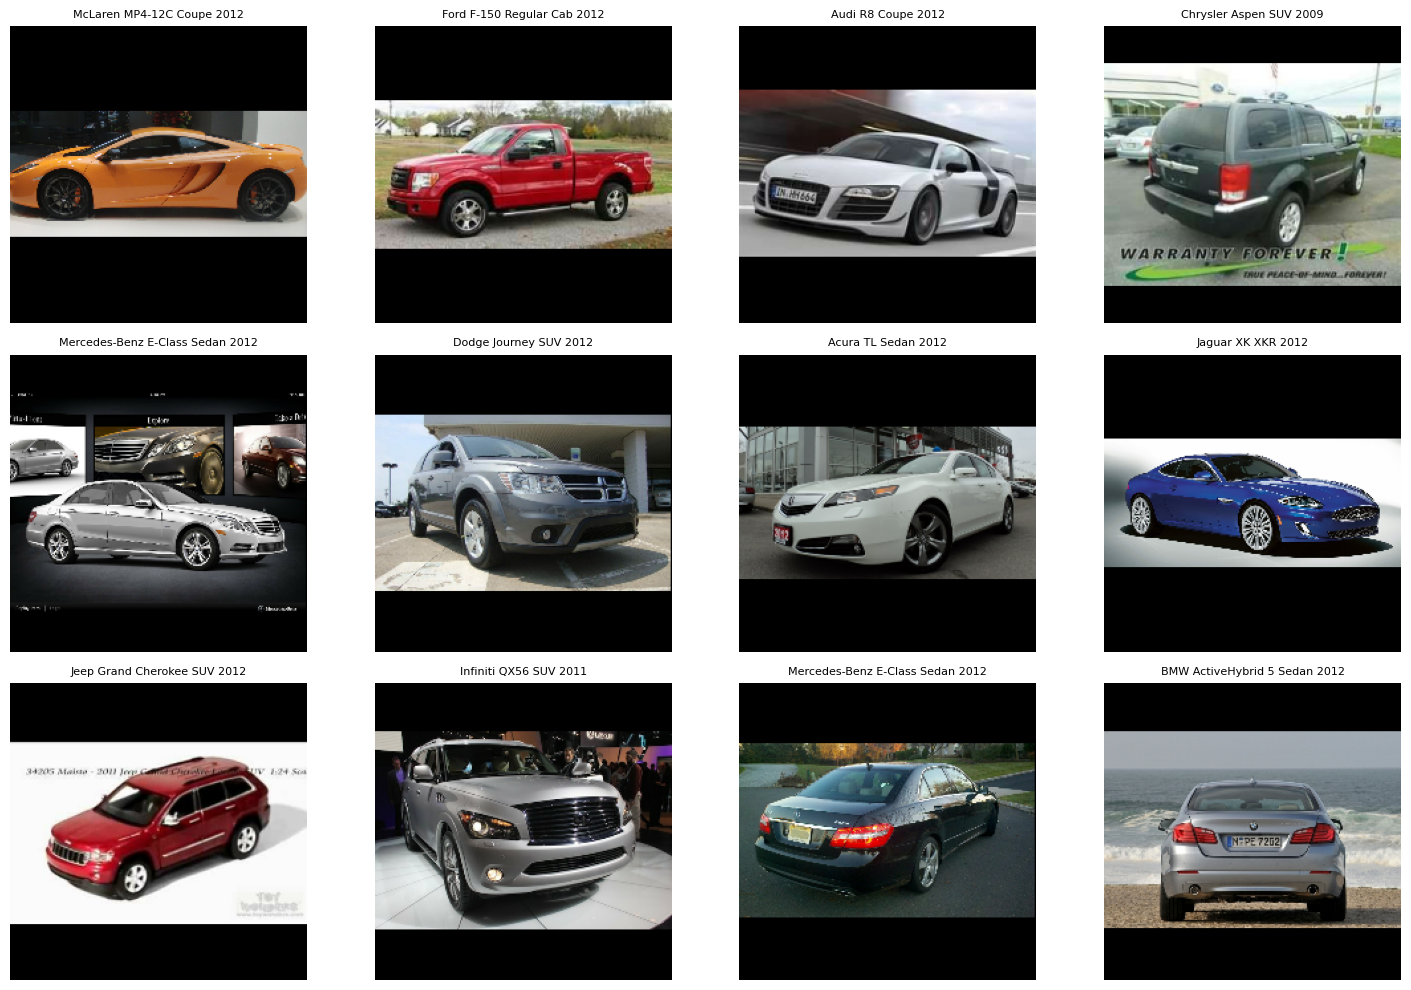

In [ ]:
mixed_images, mixed_labels = next(
    iter(mixed_train_dataset)
)

plt.figure(figsize=(15, 10))

for index in range(12):
    axis = plt.subplot(
        3,
        4,
        index + 1,
    )

    axis.imshow(
        np.clip(
            mixed_images[index].numpy(),
            0,
            255,
        ).astype("uint8")
    )

    class_index = int(
        mixed_labels[index]
    )

    axis.set_title(
        class_names[class_index],
        fontsize=8,
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
mixed_model = tf.keras.models.load_model(
    ARTIFACTS_DIR /
    "best_fine_tuned_stage2.keras"
)

mixed_base_model = mixed_model.get_layer(
    "efficientnetb0"
)

print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in mixed_base_model.layers
    ),
)

Trainable backbone layers: 24


In [ ]:
mixed_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="top1_accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy",
        ),
    ],
)

In [141]:
mixed_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=(
            ARTIFACTS_DIR /
            "best_full_image_model.keras"
        ),
        monitor="val_top1_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_top1_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=(
            ARTIFACTS_DIR /
            "mixed_training_log.csv"
        ),
    ),
]

MIXED_EPOCHS = 10

mixed_history = mixed_model.fit(
    mixed_train_dataset,
    validation_data=(
        full_validation_dataset
    ),
    epochs=MIXED_EPOCHS,
    callbacks=mixed_callbacks,
    verbose=1,
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 1.1338 - top1_accuracy: 0.7138 - top5_accuracy: 0.9069
Epoch 1: val_top1_accuracy improved from None to 0.47052, saving model to artifacts/best_full_image_model.keras

Epoch 1: finished saving model to artifacts/best_full_image_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - loss: 1.1506 - top1_accuracy: 0.7079 - top5_accuracy: 0.9038 - val_loss: 2.4700 - val_top1_accuracy: 0.4705 - val_top5_accuracy: 0.7482 - learning_rate: 5.0000e-06
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 1.0720 - top1_accuracy: 0.7277 - top5_accuracy: 0.9147
Epoch 2: val_top1_accuracy improved from 0.47052 to 0.48034, saving model to artifacts/best_full_image_model.keras

Epoch 2: finished saving model to artifacts/best_full_image_model.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - loss: 1.0904 - top1_accuracy: 0.7223 - top5_accuracy: 0.9130 - val_loss: 2.4063 - val_top1_accuracy: 0.4803 - val_top5_accuracy: 0.7604 -

In [146]:
best_mixed_epoch = int(
    np.argmax(
        mixed_history.history[
            "val_top1_accuracy"
        ]
    )
)

print(
    "Previous full-image validation top-1:",
    0.4484,
)

print(
    "Best mixed epoch:",
    best_mixed_epoch + 1,
)

print(
    "Best full-image validation top-1:",
    mixed_history.history[
        "val_top1_accuracy"
    ][best_mixed_epoch],
)

print(
    "Best full-image validation top-5:",
    mixed_history.history[
        "val_top5_accuracy"
    ][best_mixed_epoch],
)

print(
    "Best full-image validation loss:",
    mixed_history.history[
        "val_loss"
    ][best_mixed_epoch],
)

Previous full-image validation top-1: 0.4484
Best mixed epoch: 10
Best full-image validation top-1: 0.5159705281257629
Best full-image validation top-5: 0.7776412963867188
Best full-image validation loss: 2.22003436088562


In [147]:
deployment_model = (
    tf.keras.models.load_model(
        ARTIFACTS_DIR /
        "best_full_image_model.keras"
    )
)

print(
    "Loaded model:",
    deployment_model.name,
)

Loaded model: stanford_cars_efficientnet_b0


In [148]:
deployment_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-6,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="top1_accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy",
        ),
    ],
)

print(
    "Continuation learning rate:",
    3e-6,
)

Continuation learning rate: 3e-06


In [149]:
deployment_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=(
            ARTIFACTS_DIR /
            "best_full_image_stage2.keras"
        ),
        monitor="val_top1_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_top1_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=(
            ARTIFACTS_DIR /
            "mixed_training_stage2_log.csv"
        ),
    ),
]

DEPLOYMENT_EPOCHS = 6

deployment_history = deployment_model.fit(
    mixed_train_dataset,
    validation_data=(
        full_validation_dataset
    ),
    epochs=DEPLOYMENT_EPOCHS,
    callbacks=deployment_callbacks,
    verbose=1,
)

Epoch 1/6
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.9239 - top1_accuracy: 0.7491 - top5_accuracy: 0.9310
Epoch 1: val_top1_accuracy improved from None to 0.51597, saving model to artifacts/best_full_image_stage2.keras

Epoch 1: finished saving model to artifacts/best_full_image_stage2.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 64s 246ms/step - loss: 0.9602 - top1_accuracy: 0.7423 - top5_accuracy: 0.9262 - val_loss: 2.2072 - val_top1_accuracy: 0.5160 - val_top5_accuracy: 0.7764 - learning_rate: 3.0000e-06
Epoch 2/6
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.9240 - top1_accuracy: 0.7559 - top5_accuracy: 0.9350
Epoch 2: val_top1_accuracy did not improve from 0.51597
204/204 ━━━━━━━━━━━━━━━━━━━━ 64s 160ms/step - loss: 0.9460 - top1_accuracy: 0.7498 - top5_accuracy: 0.9328 - val_loss: 2.2022 - val_top1_accuracy: 0.5147 - val_top5_accuracy: 0.7764 - learning_rate: 3.0000e-06
Epoch 3/6
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.9429 - top1_accuracy: 0.7456 - top5_accura

In [150]:
best_deployment_epoch = int(
    np.argmax(
        deployment_history.history[
            "val_top1_accuracy"
        ]
    )
)

deployment_top1 = (
    deployment_history.history[
        "val_top1_accuracy"
    ][best_deployment_epoch]
)

deployment_top5 = (
    deployment_history.history[
        "val_top5_accuracy"
    ][best_deployment_epoch]
)

deployment_loss = (
    deployment_history.history[
        "val_loss"
    ][best_deployment_epoch]
)

print(
    "Previous best full-image top-1:",
    0.5159705281257629,
)

print(
    "Best continuation epoch:",
    best_deployment_epoch + 1,
)

print(
    "Best continuation top-1:",
    deployment_top1,
)

print(
    "Best continuation top-5:",
    deployment_top5,
)

print(
    "Best continuation loss:",
    deployment_loss,
)

Previous best full-image top-1: 0.5159705281257629
Best continuation epoch: 5
Best continuation top-1: 0.522113025188446
Best continuation top-5: 0.7727272510528564
Best continuation loss: 2.1766512393951416


In [151]:
if deployment_top1 > 0.5159705281257629:
    selected_model_path = (
        ARTIFACTS_DIR /
        "best_full_image_stage2.keras"
    )
else:
    selected_model_path = (
        ARTIFACTS_DIR /
        "best_full_image_model.keras"
    )

print(
    "Selected model path:",
    selected_model_path,
)

Selected model path: artifacts/best_full_image_stage2.keras


In [152]:
print(
    "Previous best full-image top-1:",
    0.5159705281257629,
)

print(
    "Best continuation epoch:",
    best_deployment_epoch + 1,
)

print(
    "Best continuation top-1:",
    deployment_top1,
)

print(
    "Best continuation top-5:",
    deployment_top5,
)

print(
    "Best continuation loss:",
    deployment_loss,
)

print(
    "Selected model path:",
    selected_model_path,
)

Previous best full-image top-1: 0.5159705281257629
Best continuation epoch: 5
Best continuation top-1: 0.522113025188446
Best continuation top-5: 0.7727272510528564
Best continuation loss: 2.1766512393951416
Selected model path: artifacts/best_full_image_stage2.keras


In [153]:
deployment_model = (
    tf.keras.models.load_model(
        selected_model_path
    )
)

print(
    "Deployment model loaded:",
    deployment_model.name,
)

Deployment model loaded: stanford_cars_efficientnet_b0


In [154]:
deployment_validation_probabilities = (
    deployment_model.predict(
        full_validation_dataset,
        verbose=1,
    )
)

deployment_validation_true = (
    validation_df[
        "class_index"
    ].to_numpy()
)

deployment_validation_predicted = (
    np.argmax(
        deployment_validation_probabilities,
        axis=1,
    )
)

deployment_validation_correct = (
    deployment_validation_predicted
    ==
    deployment_validation_true
)

sorted_probabilities = np.sort(
    deployment_validation_probabilities,
    axis=1,
)

deployment_confidences = (
    sorted_probabilities[:, -1]
)

deployment_margins = (
    sorted_probabilities[:, -1]
    -
    sorted_probabilities[:, -2]
)

print(
    "Full-image validation accuracy:",
    deployment_validation_correct.mean(),
)

print(
    "Average confidence:",
    deployment_confidences.mean(),
)

print(
    "Average margin:",
    deployment_margins.mean(),
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 383ms/step
Full-image validation accuracy: 0.5221130221130221
Average confidence: 0.64433974
Average margin: 0.5133504


In [155]:
threshold_rows = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    accepted = (
        (
            deployment_confidences
            >= threshold
        )
        &
        (
            deployment_margins
            >= 0.10
        )
    )

    accepted_count = int(
        accepted.sum()
    )

    if accepted_count == 0:
        continue

    threshold_rows.append({
        "threshold": round(
            float(threshold),
            2,
        ),
        "accepted_samples": (
            accepted_count
        ),
        "coverage_percent": round(
            accepted.mean() * 100,
            2,
        ),
        "accepted_accuracy_percent": round(
            deployment_validation_correct[
                accepted
            ].mean() * 100,
            2,
        ),
    })

deployment_threshold_df = pd.DataFrame(
    threshold_rows
)

print(
    deployment_threshold_df.to_string(
        index=False
    )
)

 threshold  accepted_samples  coverage_percent  accepted_accuracy_percent
      0.20               686             84.28                      58.02
      0.25               684             84.03                      58.19
      0.30               665             81.70                      59.40
      0.35               645             79.24                      60.31
      0.40               612             75.18                      61.76
      0.45               579             71.13                      63.56
      0.50               541             66.46                      65.80
      0.55               496             60.93                      68.75
      0.60               456             56.02                      71.27
      0.65               414             50.86                      74.15
      0.70               365             44.84                      77.53
      0.75               326             40.05                      78.22
      0.80               289          

In [156]:
DEPLOYMENT_CONFIDENCE_THRESHOLD = 0.60
DEPLOYMENT_MARGIN_THRESHOLD = 0.10

In [157]:
final_full_test_metrics = (
    deployment_model.evaluate(
        full_test_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("Final full-image test metrics:")

for metric_name, metric_value in (
    final_full_test_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - loss: 2.2496 - top1_accuracy: 0.4883 - top5_accuracy: 0.7571
Final full-image test metrics:
loss: 2.2496
top1_accuracy: 0.4883
top5_accuracy: 0.7571


In [158]:
deployment_test_probabilities = (
    deployment_model.predict(
        full_test_dataset,
        verbose=1,
    )
)

deployment_test_true = (
    test_df["class_index"].to_numpy()
)

deployment_test_predicted = np.argmax(
    deployment_test_probabilities,
    axis=1,
)

deployment_test_correct = (
    deployment_test_predicted
    ==
    deployment_test_true
)

deployment_test_sorted = np.sort(
    deployment_test_probabilities,
    axis=1,
)

deployment_test_confidences = (
    deployment_test_sorted[:, -1]
)

deployment_test_margins = (
    deployment_test_sorted[:, -1]
    -
    deployment_test_sorted[:, -2]
)

deployment_test_accepted = (
    (
        deployment_test_confidences
        >= DEPLOYMENT_CONFIDENCE_THRESHOLD
    )
    &
    (
        deployment_test_margins
        >= DEPLOYMENT_MARGIN_THRESHOLD
    )
)

print(
    "Accepted test samples:",
    deployment_test_accepted.sum(),
)

print(
    "Test coverage:",
    deployment_test_accepted.mean(),
)

print(
    "Accuracy among accepted:",
    deployment_test_correct[
        deployment_test_accepted
    ].mean(),
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step
Accepted test samples: 431
Test coverage: 0.5288343558282208
Accuracy among accepted: 0.691415313225058


In [159]:
deployment_test_top5 = np.argsort(
    deployment_test_probabilities,
    axis=1,
)[:, -5:]

deployment_test_top5_correct = np.array([
    true_index in predicted_indices
    for true_index, predicted_indices in zip(
        deployment_test_true,
        deployment_test_top5,
    )
])

print(
    "Full-image top-1 accuracy:",
    deployment_test_correct.mean(),
)

print(
    "Full-image top-5 accuracy:",
    deployment_test_top5_correct.mean(),
)

Full-image top-1 accuracy: 0.4883435582822086
Full-image top-5 accuracy: 0.7570552147239263


In [160]:
FINAL_DEPLOYMENT_MODEL_PATH = (
    ARTIFACTS_DIR /
    "car_classifier_final.keras"
)

deployment_model.save(
    FINAL_DEPLOYMENT_MODEL_PATH
)

print(
    "Final deployment model:",
    FINAL_DEPLOYMENT_MODEL_PATH.resolve(),
)

print(
    "Model size:",
    round(
        FINAL_DEPLOYMENT_MODEL_PATH
        .stat()
        .st_size
        / 1024**2,
        2,
    ),
    "MB",
)

Final deployment model: /content/artifacts/car_classifier_final.keras
Model size: 43.77 MB


In [161]:
def predict_car_with_price(
    pil_image,
    top_k=5,
):
    prepared_image = prepare_uploaded_image(
        pil_image
    )

    probabilities = (
        deployment_model.predict(
            prepared_image[None, ...],
            verbose=0,
        )[0]
    )

    sorted_indices = np.argsort(
        probabilities
    )[::-1]

    best_index = int(
        sorted_indices[0]
    )

    second_index = int(
        sorted_indices[1]
    )

    confidence = float(
        probabilities[best_index]
    )

    margin = float(
        probabilities[best_index]
        - probabilities[second_index]
    )

    accepted = (
        confidence
        >= DEPLOYMENT_CONFIDENCE_THRESHOLD
        and margin
        >= DEPLOYMENT_MARGIN_THRESHOLD
    )

    top_predictions = [
        {
            "class_name": (
                class_names[class_index]
            ),
            "probability": float(
                probabilities[class_index]
            ),
        }
        for class_index
        in sorted_indices[:top_k]
    ]

    if not accepted:
        return {
            "accepted": False,
            "make": None,
            "model": None,
            "year": None,
            "confidence": confidence,
            "margin": margin,
            "nearest_known_class": (
                class_names[best_index]
            ),
            "price": {
                "available": False,
                "reason": (
                    "Classification rejected"
                ),
            },
            "top_predictions": (
                top_predictions
            ),
        }

    parsed_class = class_lookup.loc[
        best_index
    ]

    make = parsed_class["make"]
    model_name = parsed_class["model"]
    year = int(parsed_class["year"])

    price_result = estimate_car_price(
        make=make,
        model_family=model_name,
        year=year,
    )

    return {
        "accepted": True,
        "make": make,
        "model": model_name,
        "year": year,
        "confidence": confidence,
        "margin": margin,
        "nearest_known_class": (
            class_names[best_index]
        ),
        "price": price_result,
        "top_predictions": top_predictions,
    }

In [162]:
def print_car_result(result):
    print(
        "Prediction accepted:",
        result["accepted"],
    )

    print(
        "Confidence:",
        f'{result["confidence"]:.2%}',
    )

    print(
        "Top-1/top-2 margin:",
        f'{result["margin"]:.2%}',
    )

    if not result["accepted"]:
        print(
            "Result: Unknown / unsupported"
        )

        print(
            "Nearest known class:",
            result["nearest_known_class"],
        )
    else:
        print("Make:", result["make"])
        print("Model:", result["model"])
        print("Year:", result["year"])

        price = result["price"]

        if price["available"]:
            print(
                "Estimated price:",
                f'${price["estimated_price"]:,.0f}',
            )

            print(
                "Typical range:",
                f'${price["lower_price"]:,.0f}'
                f'–${price["upper_price"]:,.0f}',
            )

            print(
                "Price fallback level:",
                price["fallback_level"],
            )

            print(
                "Price listings:",
                price["listing_count"],
            )
        else:
            print(
                "Price: unavailable"
            )

            print(
                "Price reason:",
                price["reason"],
            )

    print("\nTop predictions:")

    for position, item in enumerate(
        result["top_predictions"],
        start=1,
    ):
        print(
            f'{position}. '
            f'{item["class_name"]} — '
            f'{item["probability"]:.2%}'
        )

In [163]:
g42_result = predict_car_with_price(
    uploaded_image
)

print_car_result(g42_result)

Prediction accepted: False
Confidence: 23.68%
Top-1/top-2 margin: 2.41%
Result: Unknown / unsupported
Nearest known class: Acura TL Sedan 2012

Top predictions:
1. Acura TL Sedan 2012 — 23.68%
2. BMW M3 Coupe 2012 — 21.27%
3. Audi S4 Sedan 2012 — 9.80%
4. Porsche Panamera Sedan 2012 — 5.11%
5. BMW M5 Sedan 2010 — 4.13%


In [164]:
sample_test_rows = test_df.sample(
    5,
    random_state=7,
)

for _, row in sample_test_rows.iterrows():
    sample_image = Image.open(
        row["image_path"]
    ).convert("RGB")

    result = predict_car_with_price(
        sample_image
    )

    print("\n" + "=" * 70)
    print("Actual class:", row["class_name"])

    print_car_result(result)


Actual class: Hyundai Sonata Hybrid Sedan 2012
Prediction accepted: True
Confidence: 72.95%
Top-1/top-2 margin: 64.69%
Make: Hyundai
Model: Elantra Sedan
Year: 2007
Estimated price: $17,484
Typical range: $13,995–$19,995
Price fallback level: family
Price listings: 3739

Top predictions:
1. Hyundai Elantra Sedan 2007 — 72.95%
2. Cadillac SRX SUV 2012 — 8.25%
3. Buick Verano Sedan 2012 — 5.61%
4. Acura ZDX Hatchback 2012 — 3.71%
5. Dodge Caliber Wagon 2007 — 3.21%

Actual class: Acura Integra Type R 2001
Prediction accepted: False
Confidence: 43.17%
Top-1/top-2 margin: 16.68%
Result: Unknown / unsupported
Nearest known class: Ferrari California Convertible 2012

Top predictions:
1. Ferrari California Convertible 2012 — 43.17%
2. Aston Martin Virage Coupe 2012 — 26.49%
3. Lamborghini Diablo Coupe 2001 — 13.32%
4. Dodge Charger Sedan 2012 — 8.81%
5. Chevrolet Camaro Convertible 2012 — 2.85%

Actual class: Honda Odyssey Minivan 2012
Prediction accepted: True
Confidence: 70.22%
Top-1/top-2

VISUALS

In [165]:
!pip install -q gradio

In [166]:
def format_price_result(price_result):
    if not price_result["available"]:
        return "Price unavailable"

    estimated = (
        price_result["estimated_price"]
    )

    lower = price_result["lower_price"]
    upper = price_result["upper_price"]

    return (
        f"${estimated:,.0f} "
        f"(typical range: "
        f"${lower:,.0f}–${upper:,.0f})"
    )


def predict_for_interface(image):
    if image is None:
        return (
            "No image",
            "",
            "",
            "",
            "",
            "",
            "",
        )

    result = predict_car_with_price(
        image,
        top_k=5,
    )

    confidence_text = (
        f'{result["confidence"]:.2%}'
    )

    top_predictions_text = "\n".join(
        (
            f'{position}. '
            f'{item["class_name"]} — '
            f'{item["probability"]:.2%}'
        )
        for position, item in enumerate(
            result["top_predictions"],
            start=1,
        )
    )

    if not result["accepted"]:
        return (
            "Unknown / unsupported",
            "",
            "",
            "",
            "Price unavailable",
            confidence_text,
            top_predictions_text,
        )

    price_text = format_price_result(
        result["price"]
    )

    return (
        "Prediction accepted",
        result["make"],
        result["model"],
        str(result["year"]),
        price_text,
        confidence_text,
        top_predictions_text,
    )

In [167]:
interface_test_result = (
    predict_for_interface(
        uploaded_image
    )
)

print(
    "Number of returned fields:",
    len(interface_test_result),
)

for value in interface_test_result:
    print(value)

Number of returned fields: 7
Unknown / unsupported



Price unavailable
23.68%
1. Acura TL Sedan 2012 — 23.68%
2. BMW M3 Coupe 2012 — 21.27%
3. Audi S4 Sedan 2012 — 9.80%
4. Porsche Panamera Sedan 2012 — 5.11%
5. BMW M5 Sedan 2010 — 4.13%


In [169]:
import gradio as gr

print("Gradio version:", gr.__version__)

demo = gr.Interface(
    fn=predict_for_interface,

    inputs=gr.Image(
        type="pil",
        label="Upload a car photo",
    ),

    outputs=[
        gr.Textbox(
            label="Status",
        ),
        gr.Textbox(
            label="Make",
        ),
        gr.Textbox(
            label="Model",
        ),
        gr.Textbox(
            label="Year",
        ),
        gr.Textbox(
            label="Estimated price, USD",
        ),
        gr.Textbox(
            label="Confidence",
        ),
        gr.Textbox(
            label="Top-5 predictions",
            lines=6,
        ),
    ],

    title=(
        "Car Recognition "
        "and Price Estimation"
    ),

    description=(
        "Upload a photo containing one clearly visible car. "
        "The system recognizes only classes represented in "
        "Stanford Cars 196. Price is an approximate median "
        "listing value, not a market appraisal."
    ),

    flagging_mode="never",
)

demo.launch(
    share=True,
    debug=False,
)

Gradio version: 6.26.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfde51b159b5156dc8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [170]:
from pathlib import Path
import shutil
import json
import hashlib

EXPORT_DIR = Path(
    "fastapi_model_bundle"
)

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Export directory:",
    EXPORT_DIR.resolve(),
)

Export directory: /content/fastapi_model_bundle


In [171]:
source_model_path = (
    ARTIFACTS_DIR /
    "car_classifier_final.keras"
)

target_model_path = (
    EXPORT_DIR /
    "car_classifier.keras"
)

assert source_model_path.exists(), (
    f"Model not found: {source_model_path}"
)

shutil.copy2(
    source_model_path,
    target_model_path,
)

print(
    "Classifier copied:",
    target_model_path,
)

Classifier copied: fastapi_model_bundle/car_classifier.keras


In [172]:
CLASS_METADATA_COLUMNS = [
    "class_index",
    "class_name",
    "make",
    "model",
    "year",
    "make_normalized",
    "model_family",
]

class_metadata_export_df = (
    parsed_classes[
        CLASS_METADATA_COLUMNS
    ]
    .sort_values("class_index")
    .reset_index(drop=True)
)

assert len(
    class_metadata_export_df
) == 196

assert (
    class_metadata_export_df[
        "class_index"
    ].tolist()
    == list(range(196))
)

class_metadata_export_df.to_csv(
    EXPORT_DIR /
    "class_metadata.csv",
    index=False,
)

print(
    "Class metadata rows:",
    len(class_metadata_export_df),
)

Class metadata rows: 196


In [173]:
source_price_lookup_path = (
    ARTIFACTS_DIR /
    "price_lookup.csv"
)

target_price_lookup_path = (
    EXPORT_DIR /
    "price_lookup.csv"
)

assert source_price_lookup_path.exists(), (
    f"Price lookup not found: "
    f"{source_price_lookup_path}"
)

shutil.copy2(
    source_price_lookup_path,
    target_price_lookup_path,
)

print(
    "Price lookup copied:",
    target_price_lookup_path,
)

Price lookup copied: fastapi_model_bundle/price_lookup.csv


In [175]:
production_config = {
    "model_version": "1.0.0",
    "framework": "tensorflow",
    "tensorflow_version": tf.__version__,

    "image": {
        "height": 224,
        "width": 224,
        "channels": 3,
        "pixel_min": 0.0,
        "pixel_max": 255.0,
        "resize_method": "resize_with_pad",
        "color_mode": "RGB",
    },

    "classification": {
        "number_of_classes": 196,
        "confidence_threshold": 0.60,
        "margin_threshold": 0.10,
        "unknown_label": (
            "Unknown / unsupported"
        ),
    },

    "price": {
        "currency": "USD",
        "strategy": (
            "hierarchical_median"
        ),
        "range_quantiles": [
            0.25,
            0.75,
        ],
        "fallback_order": [
            "family_year",
            "family",
            "make_year",
            "make",
        ],
        "minimum_listings": {
            "family_year": 10,
            "family": 20,
            "make_year": 20,
            "make": 100,
        },
    },

    "metrics": {
        "full_image_test_top1": (
            0.4883435582822086
        ),
        "full_image_test_top5": (
            0.7570552147239263
        ),
        "accepted_test_coverage": (
            0.5288343558282208
        ),
        "accepted_test_accuracy": (
            0.691415313225058
        ),
        "price_test_mae_usd": (
            4863.9978
        ),
        "price_test_median_ae_usd": (
            2888.3773
        ),
        "price_test_mape": 0.1605,
        "price_test_r2": 0.7785,
    },
}

with open(
    EXPORT_DIR /
    "inference_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        production_config,
        file,
        ensure_ascii=False,
        indent=2,
    )


In [176]:
loaded_model = (
    tf.keras.models.load_model(
        EXPORT_DIR /
        "car_classifier.keras"
    )
)

loaded_metadata = pd.read_csv(
    EXPORT_DIR /
    "class_metadata.csv"
)

loaded_price_lookup = pd.read_csv(
    EXPORT_DIR /
    "price_lookup.csv"
)

with open(
    EXPORT_DIR /
    "inference_config.json",
    encoding="utf-8",
) as file:
    loaded_config = json.load(file)

print(
    "Model output shape:",
    loaded_model.output_shape,
)

print(
    "Class metadata rows:",
    len(loaded_metadata),
)

print(
    "Price lookup rows:",
    len(loaded_price_lookup),
)

print(
    "Confidence threshold:",
    loaded_config[
        "classification"
    ][
        "confidence_threshold"
    ],
)

assert loaded_model.output_shape[-1] == 196
assert len(loaded_metadata) == 196
assert len(loaded_price_lookup) == 2730

print("Bundle validation passed.")

Model output shape: (None, 196)
Class metadata rows: 196
Price lookup rows: 2730
Confidence threshold: 0.6
Bundle validation passed.


In [177]:
def calculate_sha256(file_path):
    digest = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(
            1024 * 1024
        ):
            digest.update(chunk)

    return digest.hexdigest()


manifest = {
    "bundle_version": "1.0.0",
    "files": {},
}

for file_path in sorted(
    EXPORT_DIR.iterdir()
):
    if (
        not file_path.is_file()
        or file_path.name == "manifest.json"
    ):
        continue

    manifest["files"][
        file_path.name
    ] = {
        "size_bytes": (
            file_path.stat().st_size
        ),
        "sha256": calculate_sha256(
            file_path
        ),
    }

with open(
    EXPORT_DIR / "manifest.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        indent=2,
    )

print(
    json.dumps(
        manifest,
        indent=2,
    )
)

{
  "bundle_version": "1.0.0",
  "files": {
    "car_classifier.keras": {
      "size_bytes": 45900111,
      "sha256": "016ecc7626e737a28afa66f1ad55d2efb9ce7018d3aab937acb60be41872fcfb"
    },
    "class_metadata.csv": {
      "size_bytes": 14830,
      "sha256": "bed2ae59e0f1283b31f25870880919d82c5e3cc6e323f466095b97503a44cd83"
    },
    "inference_config.json": {
      "size_bytes": 1148,
      "sha256": "35cc54dcdde020701b18173c6f8bf4e5de7c842630918d8e45d836388376e35a"
    },
    "price_lookup.csv": {
      "size_bytes": 150449,
      "sha256": "378960cb49850c60a499c5864d13525681bf7e1295c32504806d575778391a71"
    }
  }
}


In [178]:
bundle_archive_path = (
    shutil.make_archive(
        base_name=(
            "car_models_fastapi_bundle_v1"
        ),
        format="zip",
        root_dir=EXPORT_DIR,
    )
)

bundle_size_mb = (
    Path(bundle_archive_path)
    .stat()
    .st_size
    / 1024**2
)

print(
    "Bundle archive:",
    bundle_archive_path,
)

print(
    "Bundle size:",
    round(bundle_size_mb, 2),
    "MB",
)

Bundle archive: /content/car_models_fastapi_bundle_v1.zip
Bundle size: 39.78 MB


In [179]:
from google.colab import files

files.download(
    bundle_archive_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>